In [ ]:

import os
import numpy as np
import pandas as pd
from obspy import read
from obspy.core.trace import Trace
import matplotlib.pyplot as plt

In [ ]:
# ============================================================
# Event selection only (no plotting, no saving)
# - Load Excel, compute dt_rel vs FC per (station,starttime) event
# - Select events by dt_rel criteria (per scenario)
# - Match Excel events to MiniSEED traces by starttime tolerance
# - Print: per scenario list of selected events (time, station, epicentral distance)
# ============================================================

import numpy as np
import pandas as pd
from obspy import read

# -------------------------
# CONFIG
# -------------------------
xlsx  = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/data/processed/Shallow_processed_RESULTS.xlsx"
sheet = "best_7_bands_fixed_hold0"

MSEED_PATH = "/Users/ramonmargarit/Phd/Projects/Heterogeneities_Mantle/Heterogeneities-project/notebooks/All_Shallow_Moonquakes.mseed"

FC    = 5.0
BANDS = np.array([3., 4., 5., 6., 7., 8., 9.])

STARTTIME_TOL_S = 2.0

SCENARIOS = [
    dict( LOWER_TOL=0.75, MIN_POST=2, K_NEG=0, K_PRE_POS=0),
]

# -------------------------
# EXCEL LOADING / NORMALIZATION
# -------------------------
def load_excel_long(xlsx, sheet, *, FC, BANDS):
    d = pd.read_excel(xlsx, sheet_name=sheet)

    need = ["starttime", "station", "fc_hz", "t0_dt_mean"]
    missing = [c for c in need if c not in d.columns]
    if missing:
        raise KeyError(
            f"Missing columns in sheet '{sheet}': {missing}\n"
            f"Available: {list(d.columns)}"
        )

    d["station"] = d["station"].astype(str)
    d["fc_hz"]   = pd.to_numeric(d["fc_hz"], errors="coerce").astype(float)

    d["starttime_dt"]  = pd.to_datetime(d["starttime"],  errors="coerce", utc=True)
    d["t0_dt_mean_dt"] = pd.to_datetime(d["t0_dt_mean"], errors="coerce", utc=True)

    if "distance" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["distance"], errors="coerce")
    elif "epi_deg" in d.columns:
        d["distance_deg"] = pd.to_numeric(d["epi_deg"], errors="coerce")
    else:
        d["distance_deg"] = np.nan

    d = d[d["fc_hz"].isin(BANDS)].copy()

    # Excel notion of event (station + starttime)
    d["event"] = d["starttime_dt"].astype(str) + "__" + d["station"]

    # dt_rel relative to FC per event (using FC band's t0_dt_mean as reference)
    ref = (
        d[d["fc_hz"].eq(FC)][["event", "t0_dt_mean_dt"]]
        .rename(columns={"t0_dt_mean_dt": "t0_fc_dt"})
        .groupby("event", as_index=False)["t0_fc_dt"]
        .min()
    )
    d = d.merge(ref, on="event", how="left")
    d["dt_rel"] = (d["t0_dt_mean_dt"] - d["t0_fc_dt"]).dt.total_seconds()

    d = d[d["dt_rel"].notna() & d["starttime_dt"].notna() & d["t0_dt_mean_dt"].notna()].copy()

    return d[[
        "event", "station", "starttime_dt", "fc_hz", "dt_rel",
        "distance_deg", "t0_dt_mean_dt"
    ]].rename(columns={"fc_hz": "band"})


def build_event_band_matrix(df_long, *, BANDS):
    return (
        df_long.pivot_table(index="event", columns="band", values="dt_rel", aggfunc="first")
        .reindex(columns=BANDS)
        .sort_index()
    )


def select_events(*, dt_mat, FC, BANDS, MIN_POST, K_NEG, K_PRE_POS=0, LOWER_TOL=0.0):
    post_bands = [b for b in BANDS if b > FC]
    pre_bands  = [b for b in BANDS if b < FC]

    keep = []
    for ev in dt_mat.index:
        dt = dt_mat.loc[ev]

        post_vals = dt[post_bands].dropna()
        if len(post_vals) < MIN_POST:
            keep.append(False)
            continue

        n_post_nonpos = int((post_vals <= LOWER_TOL).sum())
        if n_post_nonpos > K_NEG:
            keep.append(False)
            continue

        pre_vals = dt[pre_bands].dropna()
        n_pre_pos = int((pre_vals > LOWER_TOL).sum())
        if n_pre_pos > K_PRE_POS:
            keep.append(False)
            continue

        keep.append(True)

    return pd.Series(keep, index=dt_mat.index, name="keep")


# -------------------------
# MATCH MSEED EVENTS TO EXCEL EVENTS
# -------------------------
def match_traces_to_excel_events(st, df_long, tol_s):
    by_sta = {sta: g.copy() for sta, g in df_long.groupby("station")}
    event_to_trace = {}

    for tr in st:
        sta = str(getattr(tr.stats, "station", "")).strip()
        if not sta or sta not in by_sta:
            continue

        tr_t0 = pd.Timestamp(tr.stats.starttime.datetime, tz="UTC")

        g = by_sta[sta]
        dt = (g["starttime_dt"] - tr_t0).dt.total_seconds().abs()

        j = dt.idxmin()
        if not np.isfinite(dt.loc[j]):
            continue

        if dt.loc[j] <= tol_s:
            ev = g.loc[j, "event"]

            if ev in event_to_trace:
                prev_tr, prev_diff = event_to_trace[ev]
                if dt.loc[j] < prev_diff:
                    event_to_trace[ev] = (tr, float(dt.loc[j]))
            else:
                event_to_trace[ev] = (tr, float(dt.loc[j]))

    return {ev: tr for ev, (tr, _) in event_to_trace.items()}


# -------------------------
# MAIN
# -------------------------
df_long = load_excel_long(xlsx, sheet, FC=FC, BANDS=BANDS)
dt_mat  = build_event_band_matrix(df_long, BANDS=BANDS)

# event-level distance
dist_map = (
    df_long[["event", "distance_deg"]]
    .drop_duplicates(subset=["event"])
    .set_index("event")["distance_deg"]
    .to_dict()
)

# event-level "best time": FC-band t0_dt_mean_dt
t0best_map = (
    df_long[df_long["band"] == FC][["event", "t0_dt_mean_dt"]]
    .dropna()
    .drop_duplicates(subset=["event"])
    .set_index("event")["t0_dt_mean_dt"]
    .to_dict()
)

st = read(MSEED_PATH)
event_to_trace = match_traces_to_excel_events(st, df_long, tol_s=STARTTIME_TOL_S)
print(f"Matched {len(event_to_trace)} Excel events to MiniSEED traces (tol={STARTTIME_TOL_S}s).")

for cfg in SCENARIOS:
    LOWER_TOL = float(cfg["LOWER_TOL"])
    MIN_POST  = int(cfg["MIN_POST"])
    K_NEG     = int(cfg["K_NEG"])
    K_PRE_POS = int(cfg["K_PRE_POS"])

    keep_mask = select_events(
        dt_mat=dt_mat, FC=FC, BANDS=BANDS,
        MIN_POST=MIN_POST, K_NEG=K_NEG, K_PRE_POS=K_PRE_POS,
        LOWER_TOL=LOWER_TOL
    )

    kept_events = keep_mask.index[keep_mask].tolist()
    n_kept, n_tot = int(keep_mask.sum()), int(len(keep_mask))
    print(f" Kept by dt_rel criteria: {n_kept}/{n_tot}")

    # also require a MiniSEED match
    kept_events = [ev for ev in kept_events if ev in event_to_trace]
    print(f"Kept with MiniSEED match: {len(kept_events)}/{n_kept}")

    if not kept_events:
        print(f" No events after MiniSEED matching.")
        continue

    # Build and print table
    rows = []
    for ev in kept_events:
        rows.append(dict(
            event=ev,  # <-- add this back
            time_utc=t0best_map.get(ev, pd.NaT),
            station=ev.split("__", 1)[-1],
            epi_deg=dist_map.get(ev, np.nan),
        ))

    out_df = pd.DataFrame(rows)
    out_df["epi_deg"] = pd.to_numeric(out_df["epi_deg"], errors="coerce")
    out_df = out_df.sort_values(["epi_deg", "time_utc"], na_position="last").reset_index(drop=True)

    # Print all selected events (or use .head(20) if too long)
    print(f"LOWER_TOL={LOWER_TOL}, MIN_POST={MIN_POST}, K_NEG={K_NEG}, K_PRE_POS={K_PRE_POS} \n Selected events (time_utc, station, epi_deg):")
    print(out_df.to_string(index=False))


In [ ]:
def select_trace_and_event_by_epicentral_distance(
    out_df,
    event_to_trace,
    *,
    target_deg,
    tol_deg=2.0,
    mode="closest",
    event_col="event",
    dist_col=None
):
    d = out_df.copy()

    if dist_col is None:
        if "epi_deg" in d.columns:
            dist_col = "epi_deg"
        elif "distance_deg" in d.columns:
            dist_col = "distance_deg"
        else:
            raise KeyError("out_df must contain 'epi_deg' or 'distance_deg'")

    d[dist_col] = pd.to_numeric(d[dist_col], errors="coerce")
    d = d[d[dist_col].notna()]
    if d.empty:
        return None, None, None

    win = d[(d[dist_col] >= target_deg - tol_deg) & (d[dist_col] <= target_deg + tol_deg)]
    if win.empty:
        return None, None, None

    if mode == "closest":
        idx = (win[dist_col] - target_deg).abs().idxmin()
    elif mode == "min":
        idx = win[dist_col].idxmin()
    elif mode == "max":
        idx = win[dist_col].idxmax()
    else:
        raise ValueError(f"Unknown mode: {mode}")

    if event_col not in win.columns:
        raise KeyError(f"out_df must contain '{event_col}' to map to event_to_trace")

    chosen_row = win.loc[idx]
    chosen_event = chosen_row[event_col]
    tr = event_to_trace.get(chosen_event)

    return tr, chosen_event, chosen_row


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from obspy import UTCDateTime
from scipy.signal import butter, sosfiltfilt, hilbert, get_window


In [ ]:
# ---------------------------
# Signal processing helpers
# ---------------------------
def band_edges(fc, half_bw, fs):
    """Compute lower/upper band edges for a given center frequency."""
    fl = max(fc - half_bw, 0.001)
    fu = min(fc + half_bw, 0.99 * fs / 2)
    return fl, fu

def env_and_rms(x, fs, fl, fu, win_s, order):
    """
    Bandpass x between fl, fu; return Hilbert envelope and RMS-smoothed envelope.
    """
    sos = butter(order, [fl / (fs / 2), fu / (fs / 2)], btype="bandpass", output="sos")
    bp = sosfiltfilt(sos, x)
    env = np.abs(hilbert(bp))

    N = int(round(win_s * fs)) | 1  # ensure odd length
    w = get_window("hann", N)
    w = w / w.sum()

    rms = np.sqrt(np.convolve(env**2, w, mode="same"))
    return env, rms

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from obspy import UTCDateTime
from scipy.signal import butter, sosfiltfilt, hilbert, get_window

# ---------------------------
# Signal processing helpers
# ---------------------------
def band_edges(fc, half_bw, fs):
    """Compute lower/upper band edges for a given center frequency."""
    fl = max(fc - half_bw, 0.001)
    fu = min(fc + half_bw, 0.99 * fs / 2)
    return fl, fu

def env_and_rms(x, fs, fl, fu, win_s, order):
    """
    Bandpass x between fl, fu; return Hilbert envelope and RMS-smoothed envelope.
    """
    sos = butter(order, [fl / (fs / 2), fu / (fs / 2)], btype="bandpass", output="sos")
    bp = sosfiltfilt(sos, x)
    env = np.abs(hilbert(bp))

    N = int(round(win_s * fs)) | 1  # ensure odd length
    w = get_window("hann", N)
    w = w / w.sum()

    rms = np.sqrt(np.convolve(env**2, w, mode="same"))
    return env, rms


In [ ]:

# ---------------------------
# Diffusion model + fitter
# ---------------------------
def diffusion_envelope_logamp_floor(t_eff, A, q, a, s, D, n0):
    """
    Returns log( amp_model_with_floor ), where:
      amp_total(t) = sqrt( amp_diff(t)^2 + n0^2 )
    t_eff must be time since t0 (>= small epsilon).
    """
    t_eff = np.asarray(t_eff)

    # safety floors
    q = np.clip(q, 1e-6, 0.999999)
    a = np.maximum(a, 1e-6)
    s = np.maximum(s, 1e-3)
    A = np.maximum(A, 1e-20)
    n0 = np.maximum(n0, 1e-20)
    t_eff = np.maximum(t_eff, 1e-3)

    # Eq.14 log formulation (log_e corresponds to log(amp_diff^2))
    log_e = (
        2.0 * np.log(A)
        + (a * t_eff) * np.log(q)
        - np.log(a * t_eff)
        - (D**2) / (s**2 * a * t_eff)
    )

    # log(amp_total) = 0.5*log( exp(log_e) + n0^2 )
    return 0.5 * np.log(np.exp(log_e) + n0**2)


In [ ]:

def fit_diffusion_envelope_from_t0_with_floor(t, amp, *, D, t0_mean, tmin_after_t0=5.0):
    t = np.asarray(t)
    amp = np.asarray(amp)

    # Noise floor estimated as mean value before t0_mean
    pre_mask = t < t0_mean
    if not np.any(pre_mask):
        raise RuntimeError("No samples found before t0_mean to estimate noise floor.")
    n0 = float(np.mean(amp[pre_mask]))
    n0 = max(n0, 1e-20)

    # Shift time to start at t0_mean
    t_eff = t - t0_mean

    # Fit only after t0_mean (and after optional buffer)
    mask = (t_eff > tmin_after_t0) & np.isfinite(amp) & (amp > 0)
    t_fit = t_eff[mask]
    amp_fit = amp[mask]

    if len(t_fit) < 20:
        raise RuntimeError("Not enough valid samples after t0_mean for diffusion fit")

    # Initial guess
    p0 = (
        np.median(amp_fit),  # A
        0.98,                # q
        5e-3,                # a (1/s)
        D / 4,               # s (km)
    )

    bounds = (
        (1e-20, 1e-6, 1e-6, 1e-2),
        (1e-3,  0.9999, 0.5,  1e4),
    )

    popt, pcov = curve_fit(
        lambda tt, A, q, a, s: diffusion_envelope_logamp_floor(tt, A, q, a, s, D, n0),
        t_fit,
        np.log(amp_fit),
        p0=p0,
        bounds=bounds,
        maxfev=100_000,
    )

    return popt, pcov, t_fit, amp_fit, n0


In [ ]:

# 1) Pick trace/event (your function)
tr_chosen, chosen_event, chosen_row = select_trace_and_event_by_epicentral_distance(
    out_df,
    event_to_trace,
    target_deg=46,
    tol_deg=1.0,
    mode="closest"
)

In [ ]:

# ============================================================
# MAIN SCRIPT (assumes you already have: out_df, event_to_trace,
# t0best_map, chosen_row, chosen_event, tr_chosen, etc.)
# ============================================================


print("Chosen event:", chosen_event)
print("Chosen row:\n", chosen_row)
print("Trace:\n", tr_chosen)

# 2) Excel t0 (UTC)
t0_utc = t0best_map[chosen_event]               # pd.Timestamp(UTC)
t0_obspy = UTCDateTime(t0_utc.to_pydatetime())  # ObsPy time

# 3) Define trim START (same for both), but:
#    - trimmed trace: trim start + fixed duration (end)
#    - "full tail" trace: trim start only (keep rest)
start_trim = t0_obspy - 30.0
end_trim = start_trim + 150.0  # only used for the short trimmed window

# 4) Create the short trimmed window (for fitting / close-up)
tr_trimmed = tr_chosen.copy()
tr_trimmed.trim(starttime=start_trim, endtime=end_trim)

# 5) Create the "full tail" trace: trim ONLY the beginning, keep the end
tr_tail = tr_chosen.copy()
tr_tail.trim(starttime=start_trim)  # <-- no endtime => keeps the rest of the trace

# Time axis for trimmed window (0 at start_trim)
t = tr_trimmed.times()

# t0 position on that axis
t0_line = float(t0_obspy - tr_trimmed.stats.starttime)

print("Trimmed trace start (UTC):", tr_trimmed.stats.starttime)
print("Tail trace start (UTC):   ", tr_tail.stats.starttime)
print("Excel t0 (UTC):", t0_utc)
print("Excel t0 relative to trimmed start (s):", t0_line)

# 6) Compute envelope/RMS for BOTH traces
# ---- choose your band + smoothing params here ----
fc = 5.0
half_bw = 0.5
win_s = 2    # smoothing window seconds
order = 4       # bandpass filter order

# --- trimmed RMS (fit window) ---
fs_trim = tr_trimmed.stats.sampling_rate
fl, fu = band_edges(fc, half_bw, fs_trim)
env_trim, rms = env_and_rms(tr_trimmed.data.astype(float), fs_trim, fl, fu, win_s, order)

# --- tail RMS (same start as trimmed, but extends to end) ---
fs_tail = tr_tail.stats.sampling_rate
fl_t, fu_t = band_edges(fc, half_bw, fs_tail)
env_tail, rms_tail = env_and_rms(tr_tail.data.astype(float), fs_tail, fl_t, fu_t, win_s, order)

# 7) Fit diffusion model on the trimmed RMS
D_km = float(chosen_row["epi_deg"]) * 30.0

popt, pcov, t_fit, rms_fit, n0_fit = fit_diffusion_envelope_from_t0_with_floor(
    t, rms,
    D=D_km,
    t0_mean=t0_line,
    tmin_after_t0=0   # e.g. 2.5 s if win_s=5
)

A_fit, q_fit, a_fit, s_fit = popt

print("==== Diffusion fit (Eq. 14) from t0_mean with fixed noise floor ====")
print(f"noise floor n0 = {n0_fit:.3e}")
print(f"A = {A_fit:.3e}")
print(f"q = {q_fit:.4f}")
print(f"a = {a_fit:.3e} 1/s")
print(f"s = {s_fit:.2f} km")

# 8) Evaluate model on trimmed axis (post-t0)
t_eff = t - t0_line
t_model = t_eff[t_eff > 0]
dt = 0 #win_s/2 
tt = np.maximum(t_model - dt, 1e-3)  # shift + keep positive
log_model = diffusion_envelope_logamp_floor(tt, A_fit, q_fit, a_fit, s_fit, D_km, n0_fit)
amp_model = np.exp(log_model)

# 9) Plot everything on the SAME x-axis:
#    Since tr_tail starts at start_trim too, its time axis is already aligned with t (both start at 0)
t_tail = tr_tail.times()  # 0 at start_trim (same as t=0 for trimmed)

plt.figure(figsize=(25, 6))

# --- "full tail" (beginning trimmed, end kept) ---
plt.semilogy(
    t_tail,
    rms_tail,
    color="0.7",
    alpha=0.6,
    label="Observed RMS (from start_trim to end)"
)

# --- short trimmed window ---
plt.semilogy(
    t,
    rms,
    color="k",
    label="Observed RMS (trimmed window)"
)

# --- diffusion model (over the trimmed axis) ---
plt.semilogy(
    t_model + t0_line,
    amp_model,
    linestyle="--",
    linewidth=2,
    color="tab:red",
    label="Eq. 14 fit (from t0 + noise floor)"
)

# --- Excel t0 marker ---
plt.axvline(
    t0_line,
    linestyle="--",
    color="tab:blue",
    label="Excel t0"
)
# plt.xlim(-5, 180)
plt.xlabel("Time since start_trim (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()


Linear fitting :

In [ ]:
def diffusion_envelope_amp_floor(t_eff, A, q, a, s, D, n0, dt=0.0):
    """
    Linear-amplitude diffusion envelope with noise floor and time shift.

    amp_total(t) = sqrt( amp_diff(t-dt)^2 + n0^2 )
    """
    t_eff = np.asarray(t_eff)
    tt = np.maximum(t_eff - dt, 1e-3)

    q = np.clip(q, 1e-6, 0.999999)
    a = np.maximum(a, 1e-6)
    s = np.maximum(s, 1e-3)
    A = np.maximum(A, 1e-20)
    n0 = np.maximum(n0, 1e-20)

    log_e = (
        2.0*np.log(A)
        + (a*tt)*np.log(q)
        - np.log(a*tt)
        - (D**2)/(s**2 * a * tt)
    )

    return np.sqrt(np.exp(log_e) + n0**2)


In [ ]:
def fit_diffusion_envelope_from_t0_linear_unweighted(
    t, amp, *, D, t0_mean, tmin_after_t0=0.0, fit_dt=True
):
    t = np.asarray(t)
    amp = np.asarray(amp)

    # --- noise floor ---
    pre_mask = t < t0_mean
    if not np.any(pre_mask):
        raise RuntimeError("No samples before t0_mean for noise floor")

    n0 = float(np.median(amp[pre_mask]))
    n0 = max(n0, 1e-20)

    # --- effective time ---
    t_eff = t - t0_mean
    mask = (t_eff > tmin_after_t0) & np.isfinite(amp) & (amp > 0)

    t_fit = t_eff[mask]
    amp_fit = amp[mask]

    if len(t_fit) < 20:
        raise RuntimeError("Not enough samples for diffusion fit")

    # --- initial guess & bounds ---
    if fit_dt:
        p0 = (
            np.median(amp_fit),  # A
            0.98,                # q
            5e-3,                # a
            D / 4,               # s
            0.0,                 # dt
        )
        bounds = (
            (1e-20, 1e-6, 1e-6, 1e-2,  -50.0),
            (1e-3,  0.9999, 0.5,  1e4,  +50.0),
        )

        popt, pcov = curve_fit(
            lambda tt, A, q, a, s, dt:
                diffusion_envelope_amp_floor(tt, A, q, a, s, D, n0, dt),
            t_fit,
            amp_fit,
            p0=p0,
            bounds=bounds,
            maxfev=200_000,
        )

        A, q, a, s, dt = popt

    else:
        p0 = (
            np.median(amp_fit),
            0.98,
            5e-3,
            D / 4,
        )
        bounds = (
            (1e-20, 1e-6, 1e-6, 1e-2),
            (1e-3,  0.9999, 0.5,  1e4),
        )

        popt, pcov = curve_fit(
            lambda tt, A, q, a, s:
                diffusion_envelope_amp_floor(tt, A, q, a, s, D, n0),
            t_fit,
            amp_fit,
            p0=p0,
            bounds=bounds,
            maxfev=200_000,
        )

        A, q, a, s = popt
        dt = 0.0

    # --- model on fit points ---
    amp_model_fit = diffusion_envelope_amp_floor(
        t_fit, A, q, a, s, D, n0, dt
    )

    # --- misfit diagnostics ---
    residual = amp_fit - amp_model_fit

    rms_misfit = np.sqrt(np.mean(residual**2))
    rel_rms_misfit = np.sqrt(np.mean((residual / amp_fit)**2))

    # log-space diagnostic only
    log_misfit = np.sqrt(
        np.mean((np.log(amp_fit) - np.log(amp_model_fit))**2)
    )

    misfit = {
        "RMS": rms_misfit,
        "Relative_RMS": rel_rms_misfit,
        "Log_RMS": log_misfit,
    }

    return popt, pcov, t_fit, amp_fit, n0, misfit


In [ ]:
popt, pcov, t_fit, rms_fit, n0_fit, misfit = \
    fit_diffusion_envelope_from_t0_linear_unweighted(
        t,
        rms,
        D=D_km,
        t0_mean=t0_line,
        tmin_after_t0=win_s/2,
        fit_dt=True
    )

A, q, a, s, dt = popt

print("==== Unweighted linear diffusion fit ====")
print(f"n0 = {n0_fit:.3e}")
print(f"A  = {A:.3e}")
print(f"q  = {q:.4f}")
print(f"a  = {a:.3e} 1/s")
print(f"s  = {s:.2f} km")
print(f"dt = {dt:.2f} s")

print("\n==== Misfit ====")
print(f"RMS misfit          = {misfit['RMS']:.3e}")
print(f"Relative RMS misfit = {100*misfit['Relative_RMS']:.2f} %")
print(f"Log RMS misfit      = {misfit['Log_RMS']:.3f}")


In [ ]:
t_eff = t - t0_line
t_model = t_eff[t_eff > 0]


amp_model_fit = diffusion_envelope_amp_floor(
        t_fit, A, q, a, s, D_km, n0_fit, dt
    )


In [ ]:

plt.figure(figsize=(25, 6))

# --- "full tail" (beginning trimmed, end kept) ---
plt.plot(
    t_tail,
    rms_tail,
    color="0.7",
    alpha=0.6,
    label="Observed RMS (from start_trim to end)"
)

# --- short trimmed window ---
plt.plot(
    t,
    rms,
    color="k",
    label="Observed RMS (trimmed window)"
)

# --- diffusion model (over the trimmed axis) ---
plt.plot(
    t_model + t0_line,
    amp_model,
    linestyle="--",
    linewidth=2,
    color="tab:red",
    label="Eq. 14 fit (from t0 + noise floor)"
)

# --- Excel t0 marker ---
plt.axvline(
    t0_line,
    linestyle="--",
    color="tab:blue",
    label="Excel t0"
)
# plt.xlim(-5, 180)
plt.xlabel("Time since start_trim (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from scipy.optimize import curve_fit

# ---------------------------
# Linear diffusion model
# ---------------------------
def diffusion_envelope_amp_floor(t_eff, A, q, a, s, D, n0, dt=0.0):
    """
    Linear-amplitude diffusion envelope with noise floor and optional time shift.

    amp_total(t) = sqrt( amp_diff(t-dt)^2 + n0^2 )
    """
    t_eff = np.asarray(t_eff)
    tt = np.maximum(t_eff - dt, 1e-3)

    q = np.clip(q, 1e-6, 0.999999)
    a = np.maximum(a, 1e-6)
    s = np.maximum(s, 1e-3)
    A = np.maximum(A, 1e-20)
    n0 = np.maximum(n0, 1e-20)

    # log(amp_diff^2)
    log_e = (
        2.0 * np.log(A)
        + (a * tt) * np.log(q)
        - np.log(a * tt)
        - (D**2) / (s**2 * a * tt)
    )

    return np.sqrt(np.exp(log_e) + n0**2)


# ---------------------------
# Weighted linear fitter + misfit
# ---------------------------
def fit_diffusion_envelope_from_t0_linear_weighted(
    t, amp, *, D, t0_mean, tmin_after_t0=0.0, fit_dt=True, weight_mode="hybrid"
):
    """
    Fits diffusion envelope in LINEAR amplitude with weights.
    Returns popt, pcov, t_fit, amp_fit, n0, sigma, misfit_dict.

    weight_mode:
      - "hybrid": sigma = sqrt(amp_fit^2 + n0^2)   (recommended)
      - "relative": sigma = max(amp_fit, n0)
      - "noise": sigma = n0
    """
    t = np.asarray(t)
    amp = np.asarray(amp)

    # --- noise floor from pre-event ---
    pre_mask = t < t0_mean
    if not np.any(pre_mask):
        raise RuntimeError("No samples before t0_mean for noise floor estimate.")
    n0 = float(np.median(amp[pre_mask]))
    n0 = max(n0, 1e-20)

    # --- effective time ---
    t_eff = t - t0_mean

    # --- fit mask ---
    mask = (t_eff > tmin_after_t0) & np.isfinite(amp) & (amp > 0)
    t_fit = t_eff[mask]
    amp_fit = amp[mask]

    if len(t_fit) < 20:
        raise RuntimeError("Not enough valid samples after t0_mean for diffusion fit")

    # --- weights (sigma) ---
    if weight_mode == "hybrid":
        sigma = np.sqrt(amp_fit**2 + n0**2)
    elif weight_mode == "relative":
        sigma = np.maximum(amp_fit, n0)
    elif weight_mode == "noise":
        sigma = np.full_like(amp_fit, n0)
    else:
        raise ValueError("weight_mode must be one of: 'hybrid', 'relative', 'noise'")

    # --- initial guess ---
    if fit_dt:
        p0 = (
            np.median(amp_fit),  # A
            0.98,                # q
            5e-3,                # a (1/s)
            D / 4,               # s (km)
            0.0,                 # dt (s)
        )
        bounds = (
            (1e-20, 1e-6, 1e-6, 1e-2,  -50.0),
            (1e-3,  0.9999, 0.5,  1e4,  +50.0),
        )

        popt, pcov = curve_fit(
            lambda tt, A, q, a, s, dt: diffusion_envelope_amp_floor(tt, A, q, a, s, D, n0, dt),
            t_fit,
            amp_fit,
            p0=p0,
            bounds=bounds,
            sigma=sigma,
            absolute_sigma=False,
            maxfev=200_000,
        )
        A_fit, q_fit, a_fit, s_fit, dt_fit = popt

    else:
        p0 = (
            np.median(amp_fit),  # A
            0.98,                # q
            5e-3,                # a (1/s)
            D / 4,               # s (km)
        )
        bounds = (
            (1e-20, 1e-6, 1e-6, 1e-2),
            (1e-3,  0.9999, 0.5,  1e4),
        )

        popt, pcov = curve_fit(
            lambda tt, A, q, a, s: diffusion_envelope_amp_floor(tt, A, q, a, s, D, n0, 0.0),
            t_fit,
            amp_fit,
            p0=p0,
            bounds=bounds,
            sigma=sigma,
            absolute_sigma=False,
            maxfev=200_000,
        )
        A_fit, q_fit, a_fit, s_fit = popt
        dt_fit = 0.0

    # --- model on fit points ---
    amp_model_fit = diffusion_envelope_amp_floor(t_fit, A_fit, q_fit, a_fit, s_fit, D, n0, dt_fit)
    residual = amp_fit - amp_model_fit

    # --- misfits ---
    wrms = np.sqrt(np.mean((residual / sigma) ** 2))                      # weighted RMS
    rrms = np.sqrt(np.mean((residual / amp_fit) ** 2))                    # relative RMS
    log_rms = np.sqrt(np.mean((np.log(amp_fit) - np.log(amp_model_fit))**2))  # log RMS (diagnostic)

    misfit = {
        "WRMS": wrms,
        "Relative_RMS": rrms,
        "Log_RMS": log_rms,
    }

    return popt, pcov, t_fit, amp_fit, n0, sigma, misfit


# ============================================================
# Example usage in your script (drop-in)
# ============================================================

popt, pcov, t_fit, rms_fit, n0_fit, sigma, misfit = fit_diffusion_envelope_from_t0_linear_weighted(
    t,
    rms,
    D=D_km,
    t0_mean=t0_line,
    tmin_after_t0=win_s/2,   # usually a good idea with RMS smoothing
    fit_dt=True,
    weight_mode="hybrid",    # "hybrid" recommended
)

A_fit, q_fit, a_fit, s_fit, dt_fit = popt

print("==== Weighted linear diffusion fit ====")
print(f"n0 = {n0_fit:.3e}")
print(f"A  = {A_fit:.3e}")
print(f"q  = {q_fit:.4f}")
print(f"a  = {a_fit:.3e} 1/s")
print(f"s  = {s_fit:.2f} km")
print(f"dt = {dt_fit:.2f} s")

print("\n==== Misfit ====")
print(f"WRMS (weighted)       = {misfit['WRMS']:.3f}")
print(f"Relative RMS          = {100*misfit['Relative_RMS']:.2f} %")
print(f"Log RMS (diagnostic)  = {misfit['Log_RMS']:.3f}")

# Evaluate model for plotting on full trimmed axis:
t_eff = t - t0_line
t_model = t_eff[t_eff > 0]
amp_model = diffusion_envelope_amp_floor(t_model, A_fit, q_fit, a_fit, s_fit, D_km, n0_fit, dt_fit)


In [ ]:

plt.figure(figsize=(25, 6))

# --- "full tail" (beginning trimmed, end kept) ---
plt.plot(
    t_tail,
    rms_tail,
    color="0.7",
    alpha=0.6,
    label="Observed RMS (from start_trim to end)"
)

# --- short trimmed window ---
plt.plot(
    t,
    rms,
    color="k",
    label="Observed RMS (trimmed window)"
)

# --- diffusion model (over the trimmed axis) ---
plt.plot(
    t_model + t0_line,
    amp_model,
    linestyle="--",
    linewidth=2,
    color="tab:red",
    label="Eq. 14 fit (from t0 + noise floor)"
)

# --- Excel t0 marker ---
plt.axvline(
    t0_line,
    linestyle="--",
    color="tab:blue",
    label="Excel t0"
)
# plt.xlim(-5, 180)
plt.xlabel("Time since start_trim (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()


Chosen event: 1971-05-20 17:16:10.013000+00:00__S14
Epi distance: 46.0

==== LOG fit (fit in log-amplitude) ====
n0 = 1.481e-11
A  = 4.189e-09
q  = 0.999999
a  = 2.526e+00 1/s
s  = 129.60 km
dt = 0.00 s
---- Misfit ----
RMS                  = 8.882e-11
Relative RMS         = 50.45 %
Log RMS              = 0.434

==== LINEAR fit (weighted) ====
n0 = 1.481e-11
A  = 1.166e-09
q  = 0.999999
a  = 3.774e-01 1/s
s  = 344.54 km
dt = 0.00 s
---- Misfit ----
WRMS (weighted)      = 0.409
RMS                  = 1.121e-10
Relative RMS         = 41.50 %
Log RMS              = 0.510


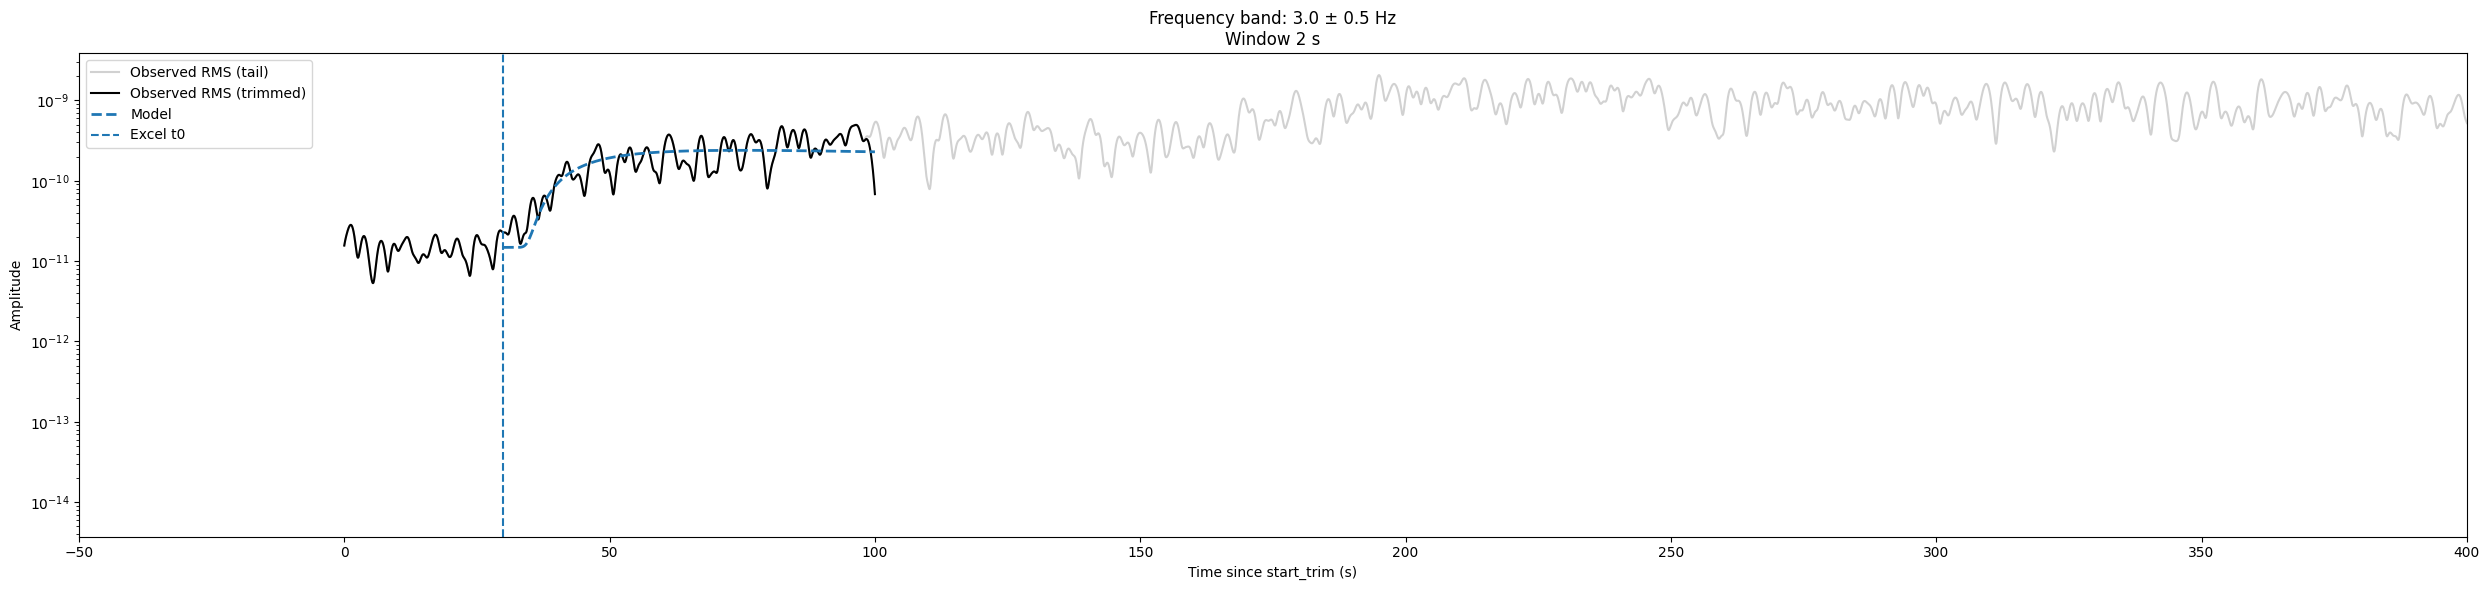

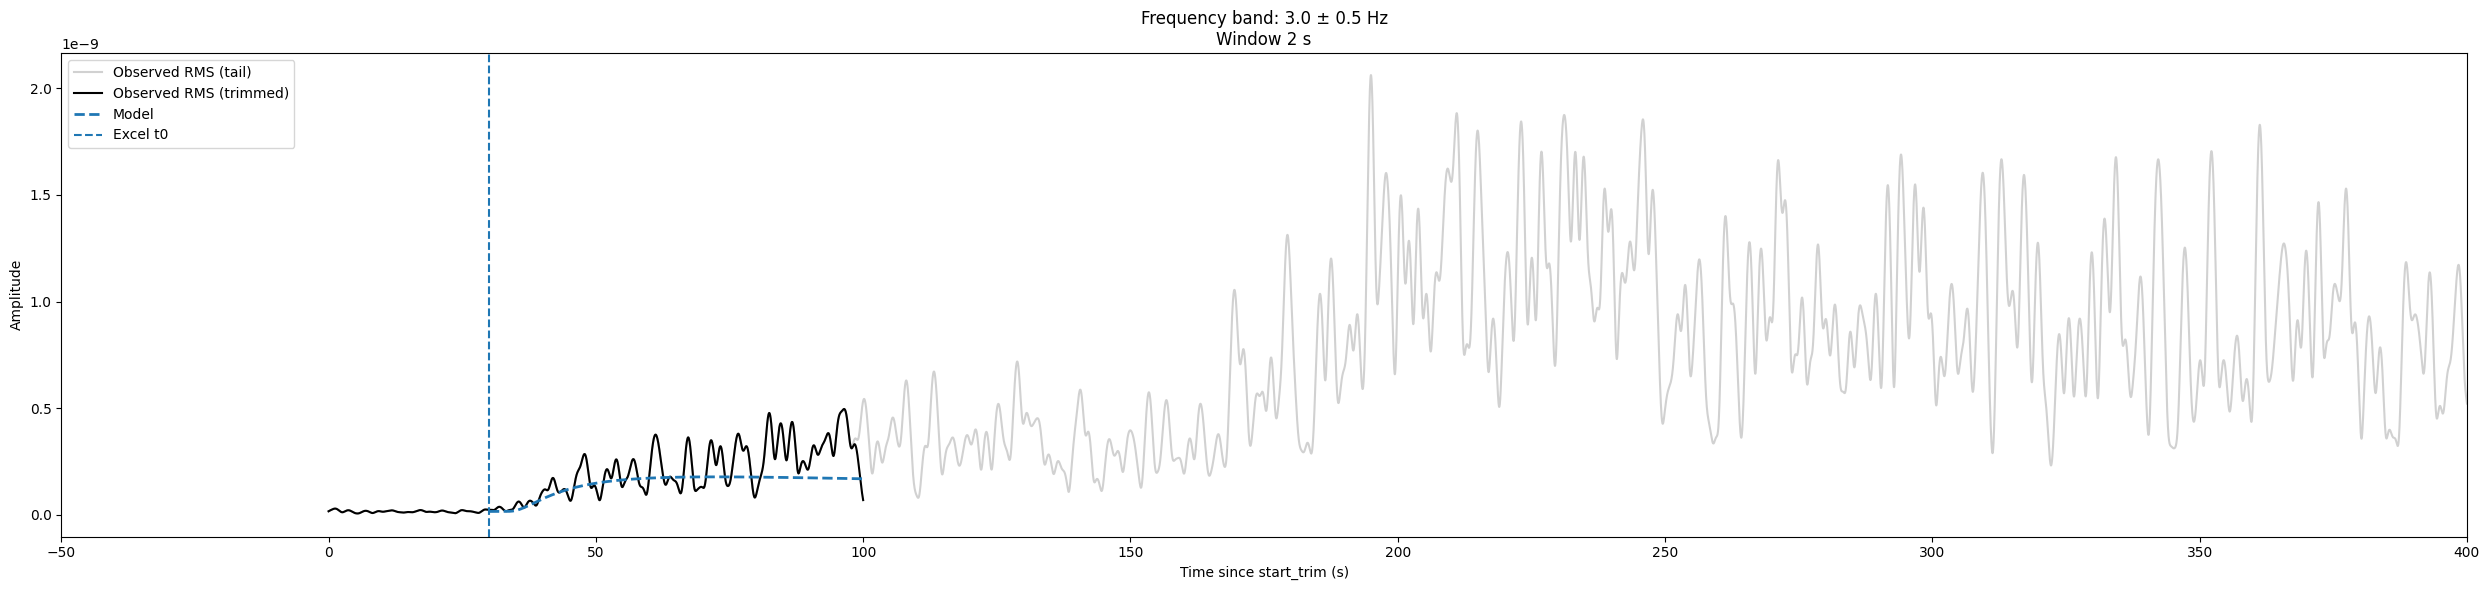


==== LOG fit (fit in log-amplitude) ====
n0 = 2.389e-11
A  = 3.270e-09
q  = 0.308922
a  = 4.927e-02 1/s
s  = 601.62 km
dt = 0.00 s
---- Misfit ----
RMS                  = 9.006e-11
Relative RMS         = 61.70 %
Log RMS              = 0.532

==== LINEAR fit (weighted) ====
n0 = 2.389e-11
A  = 2.252e-09
q  = 0.885543
a  = 3.111e-01 1/s
s  = 301.16 km
dt = 0.00 s
---- Misfit ----
WRMS (weighted)      = 0.432
RMS                  = 1.049e-10
Relative RMS         = 49.59 %
Log RMS              = 0.597


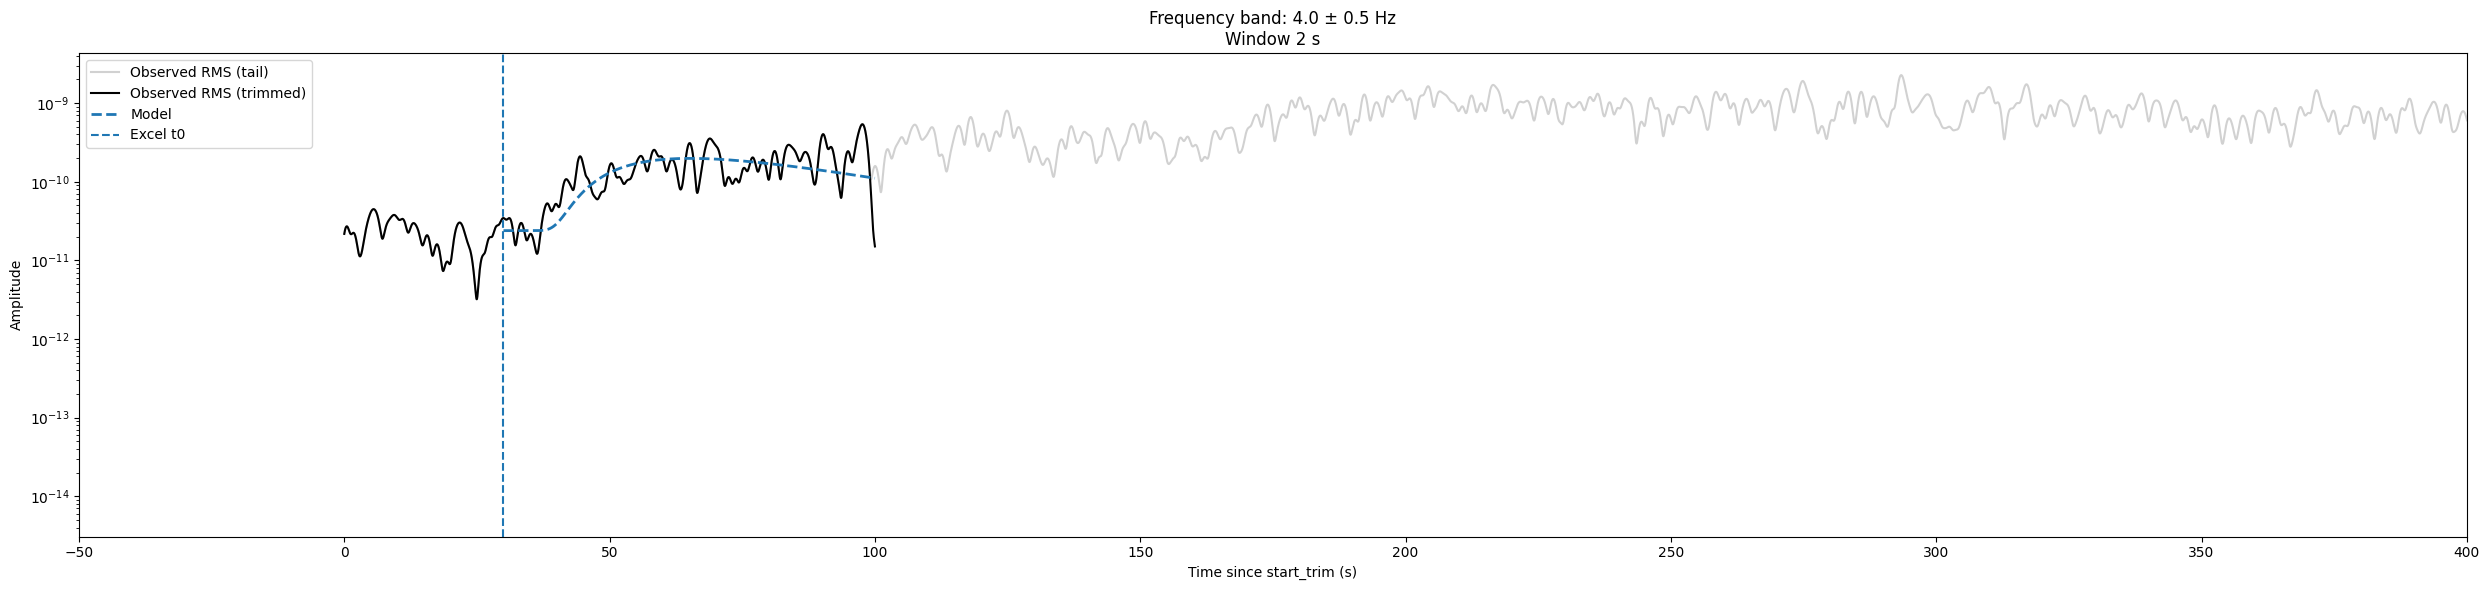

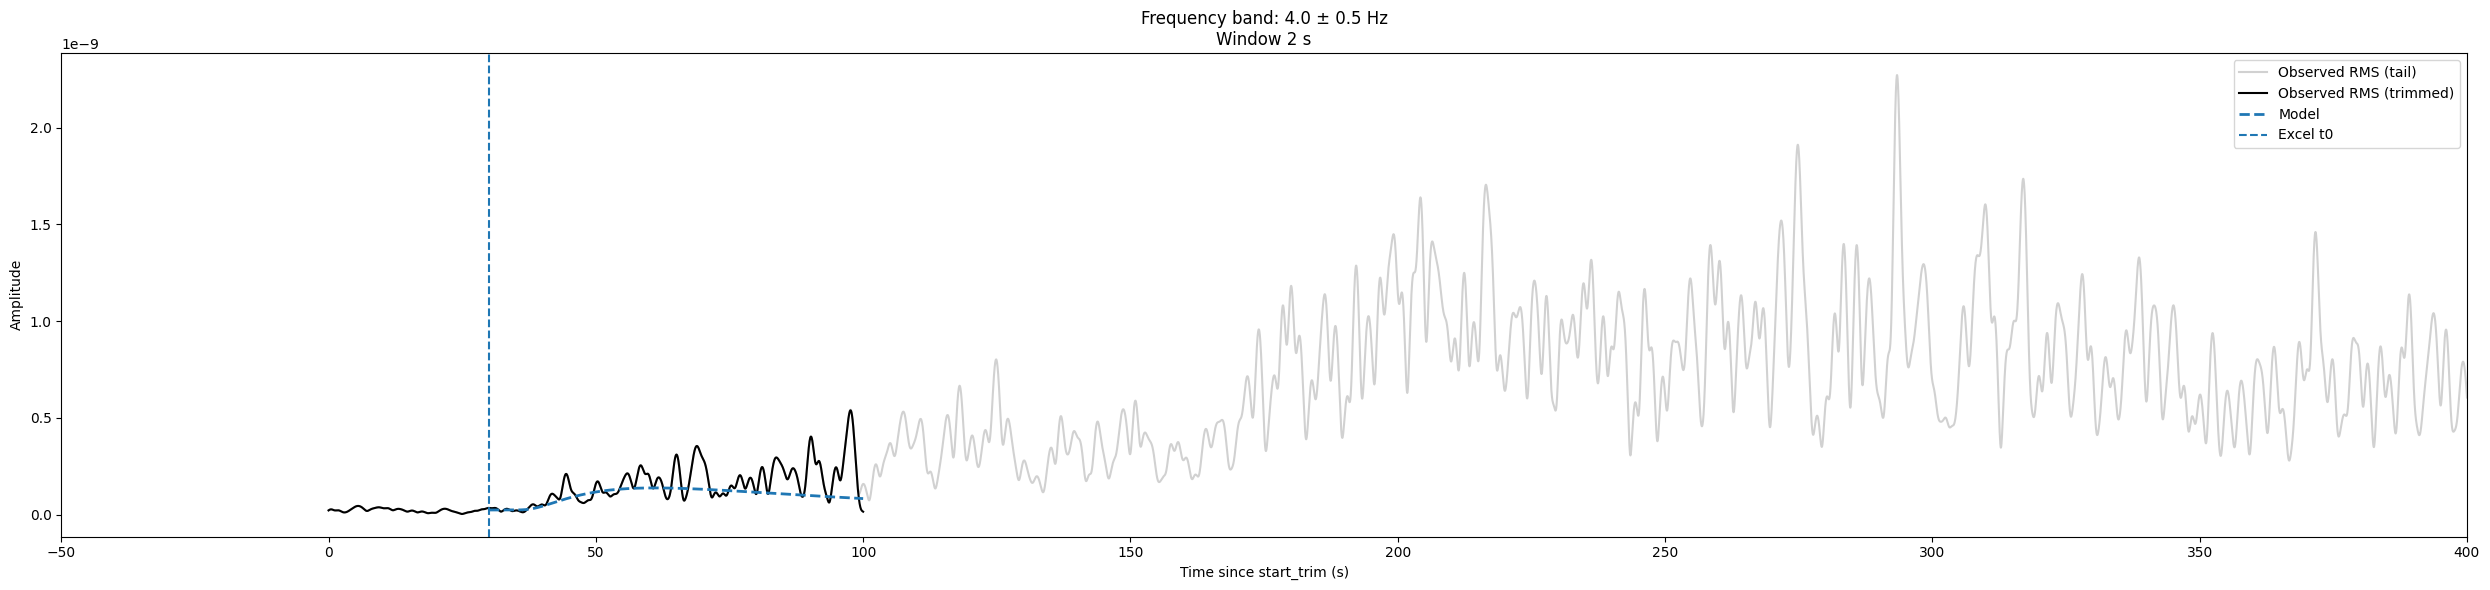


==== LOG fit (fit in log-amplitude) ====
n0 = 1.219e-11
A  = 3.289e-09
q  = 0.914656
a  = 3.312e-01 1/s
s  = 256.55 km
dt = 0.00 s
---- Misfit ----
RMS                  = 6.220e-11
Relative RMS         = 45.98 %
Log RMS              = 0.442

==== LINEAR fit (weighted) ====
n0 = 1.219e-11
A  = 1.544e-09
q  = 0.999999
a  = 8.566e-01 1/s
s  = 192.03 km
dt = 0.00 s
---- Misfit ----
WRMS (weighted)      = 0.367
RMS                  = 6.992e-11
Relative RMS         = 38.22 %
Log RMS              = 0.451


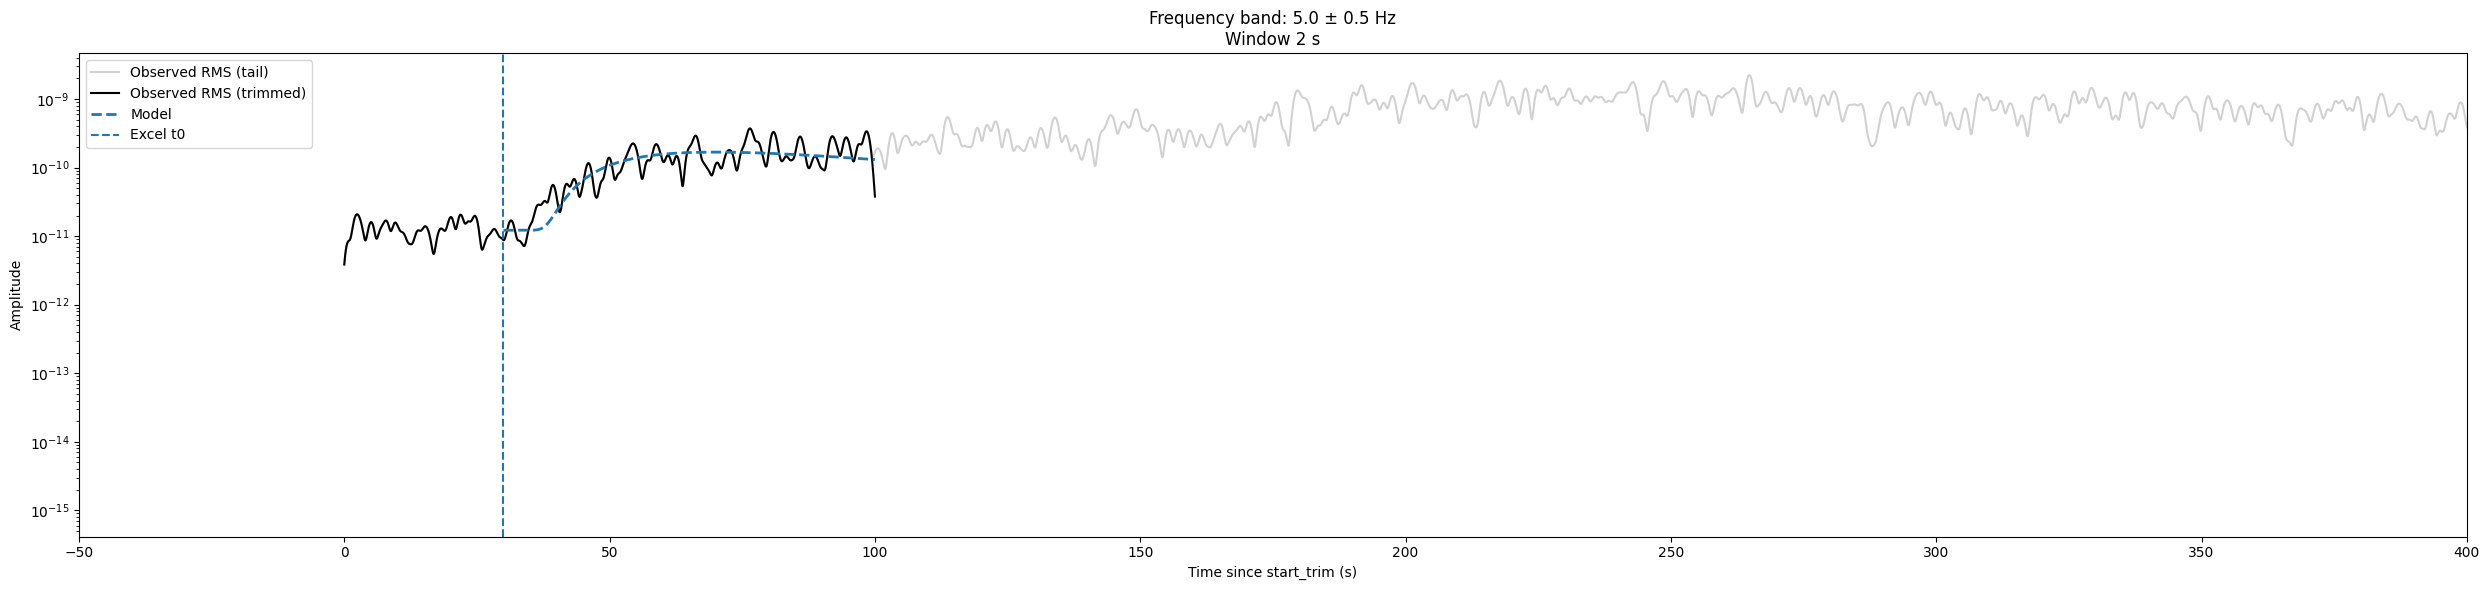

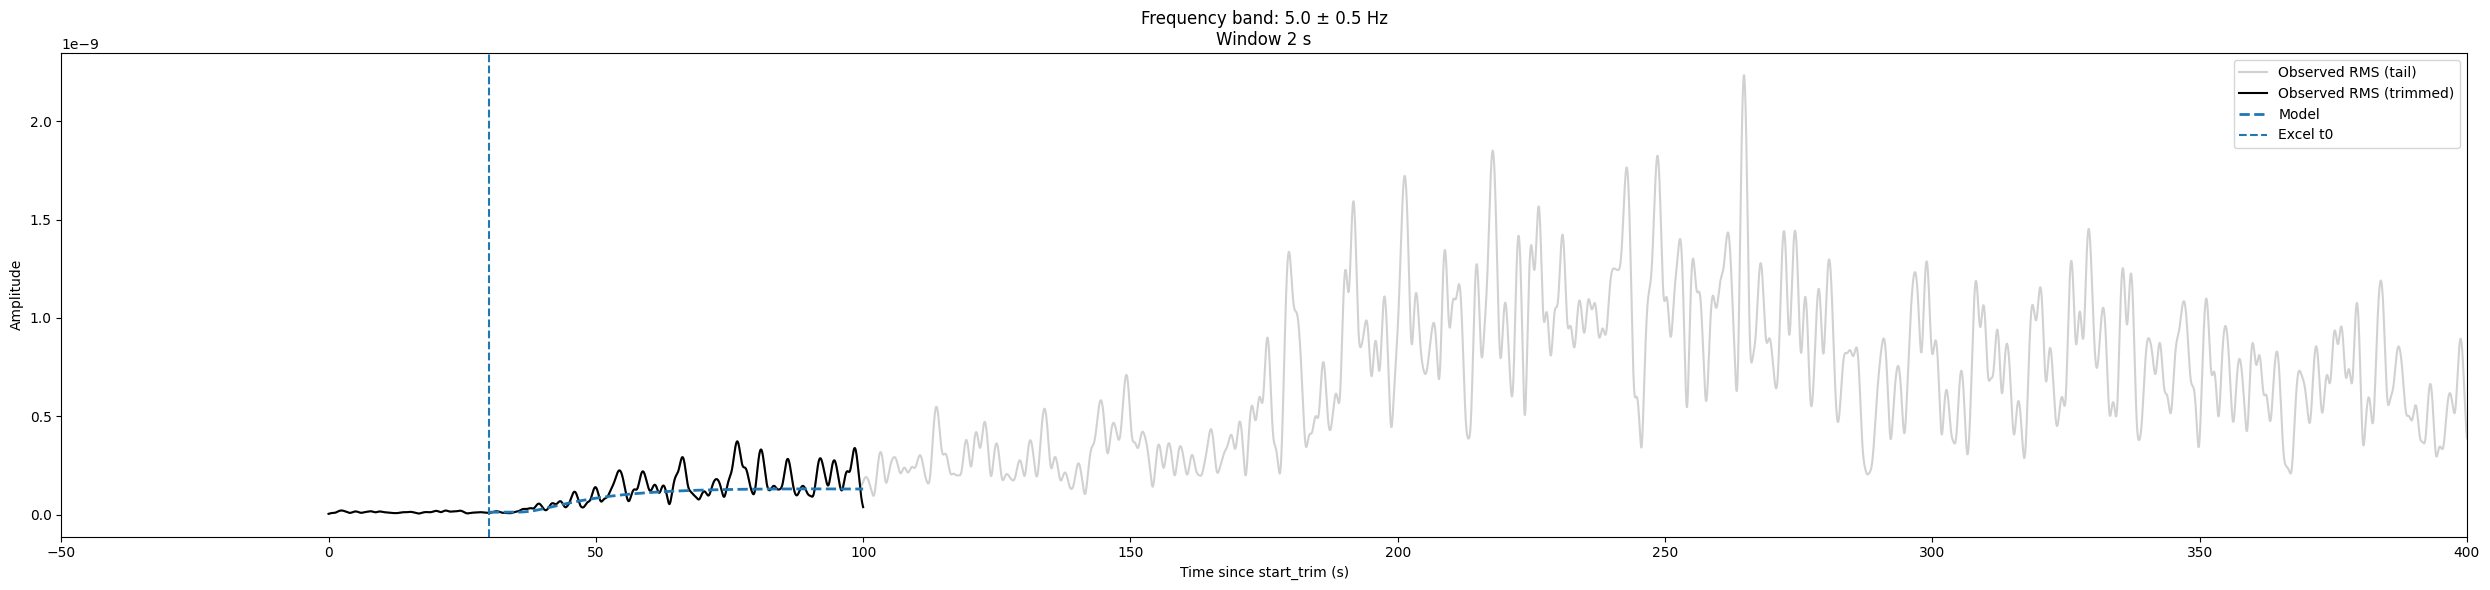


==== LOG fit (fit in log-amplitude) ====
n0 = 9.269e-12
A  = 3.027e-09
q  = 0.763098
a  = 1.364e-01 1/s
s  = 372.23 km
dt = 0.00 s
---- Misfit ----
RMS                  = 6.551e-11
Relative RMS         = 82.98 %
Log RMS              = 0.523

==== LINEAR fit (weighted) ====
n0 = 9.269e-12
A  = 1.088e-09
q  = 0.999999
a  = 4.709e-01 1/s
s  = 237.90 km
dt = 0.00 s
---- Misfit ----
WRMS (weighted)      = 0.507
RMS                  = 8.516e-11
Relative RMS         = 56.93 %
Log RMS              = 0.639


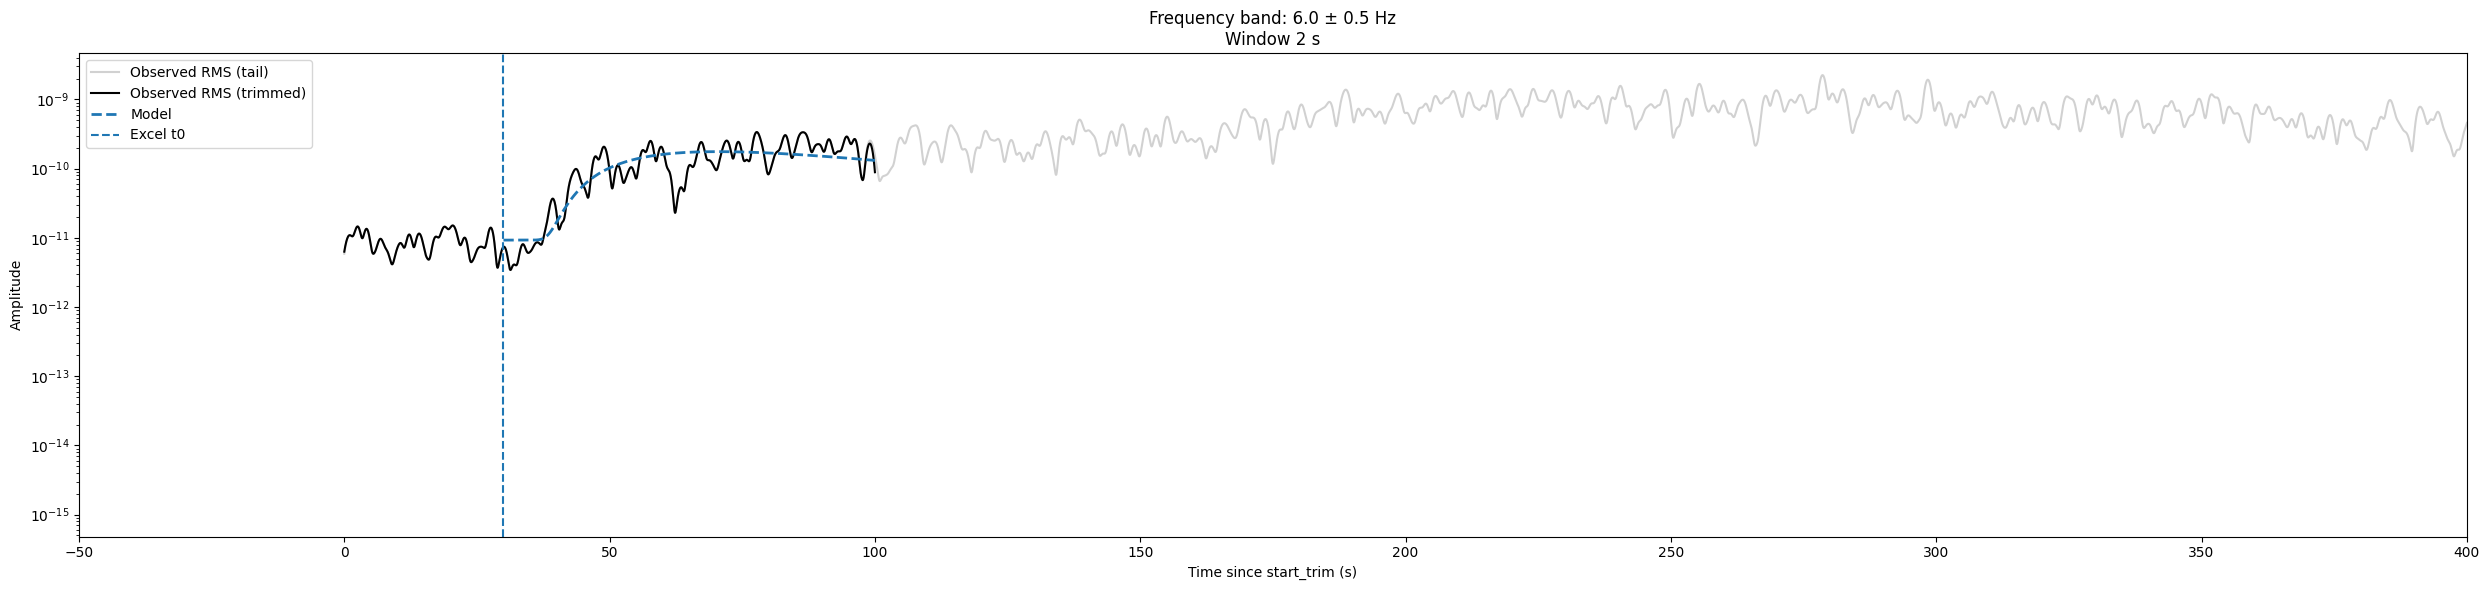

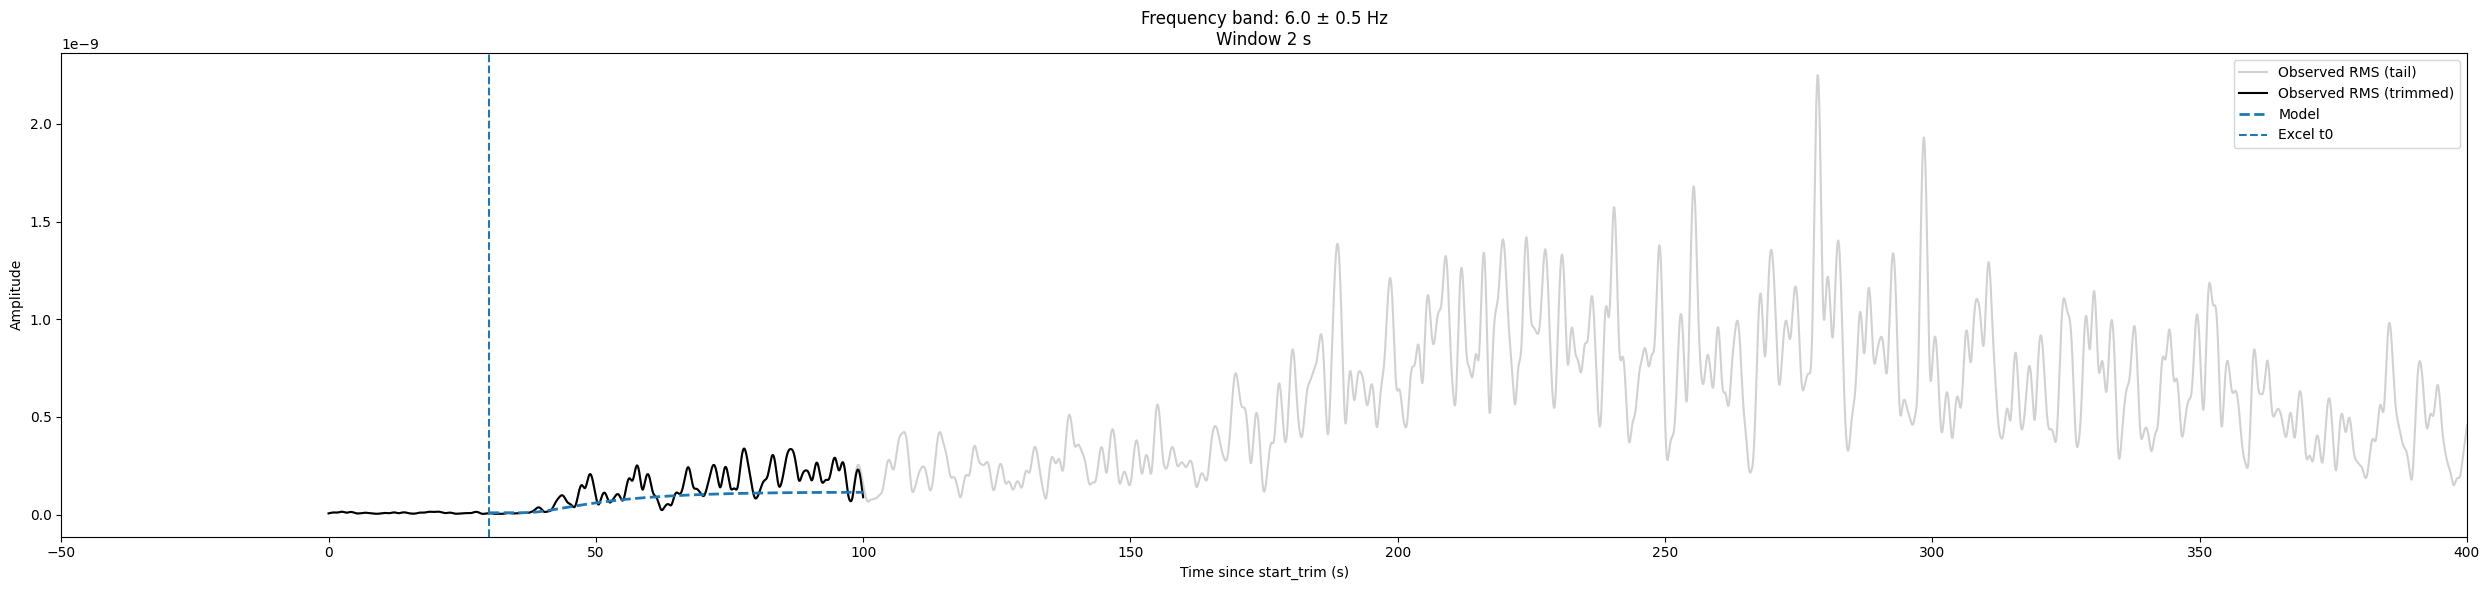


==== LOG fit (fit in log-amplitude) ====
n0 = 7.184e-12
A  = 5.167e-09
q  = 0.999960
a  = 3.629e+00 1/s
s  = 77.93 km
dt = 0.00 s
---- Misfit ----
RMS                  = 5.731e-11
Relative RMS         = 51.28 %
Log RMS              = 0.394

==== LINEAR fit (weighted) ====
n0 = 7.184e-12
A  = 1.507e-09
q  = 0.951497
a  = 2.941e-01 1/s
s  = 273.10 km
dt = 0.00 s
---- Misfit ----
WRMS (weighted)      = 0.386
RMS                  = 7.668e-11
Relative RMS         = 41.86 %
Log RMS              = 0.490


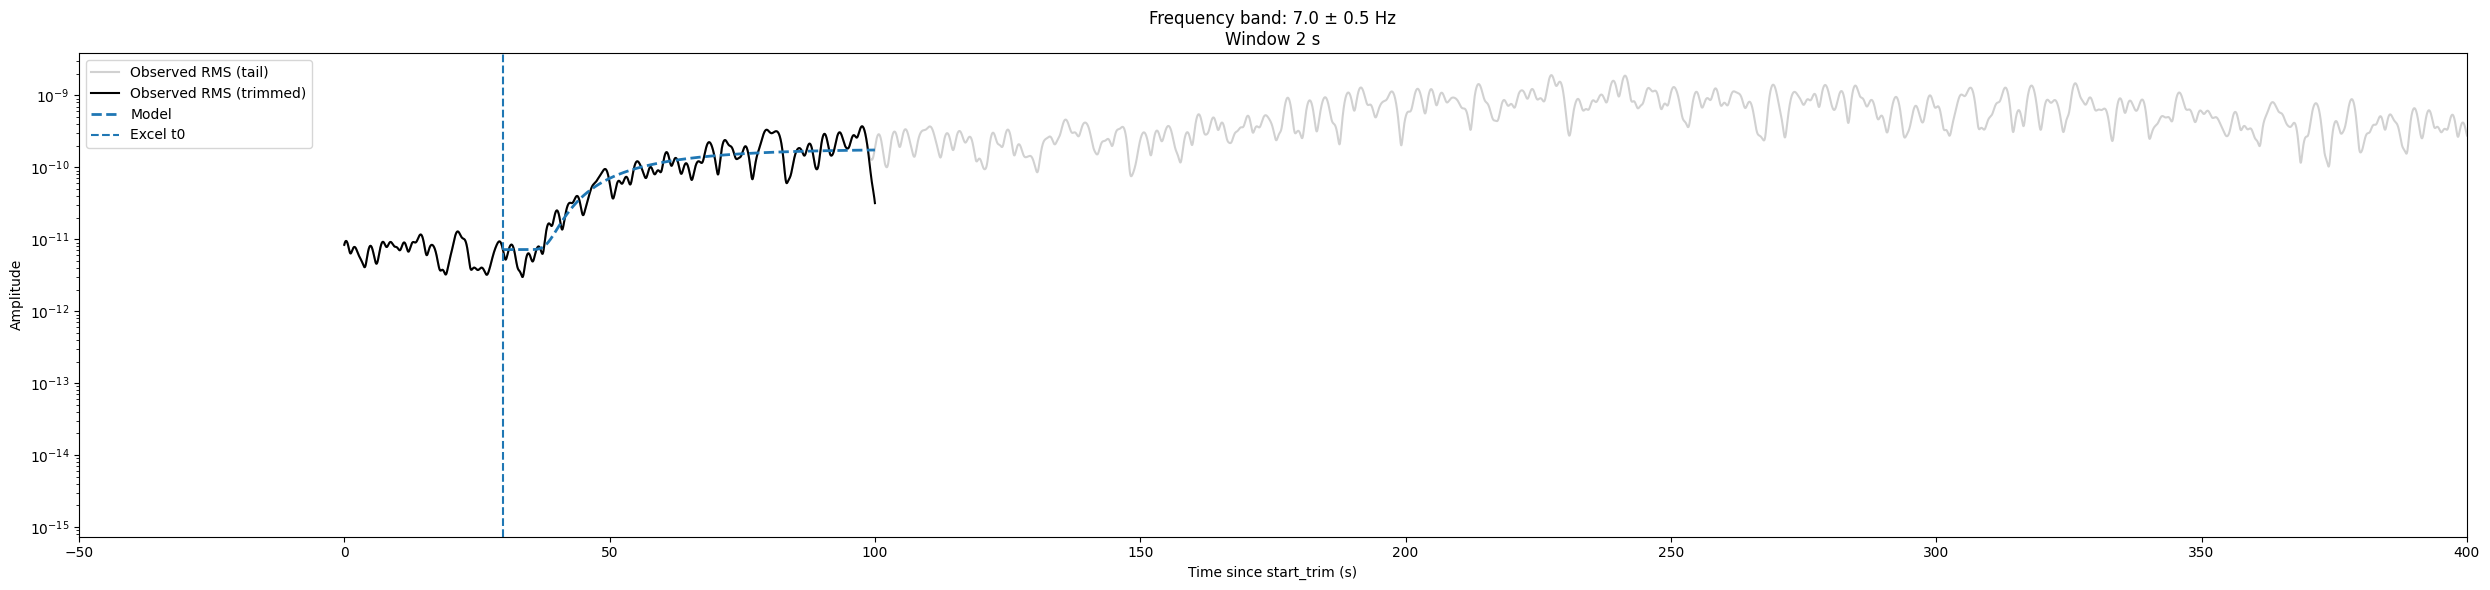

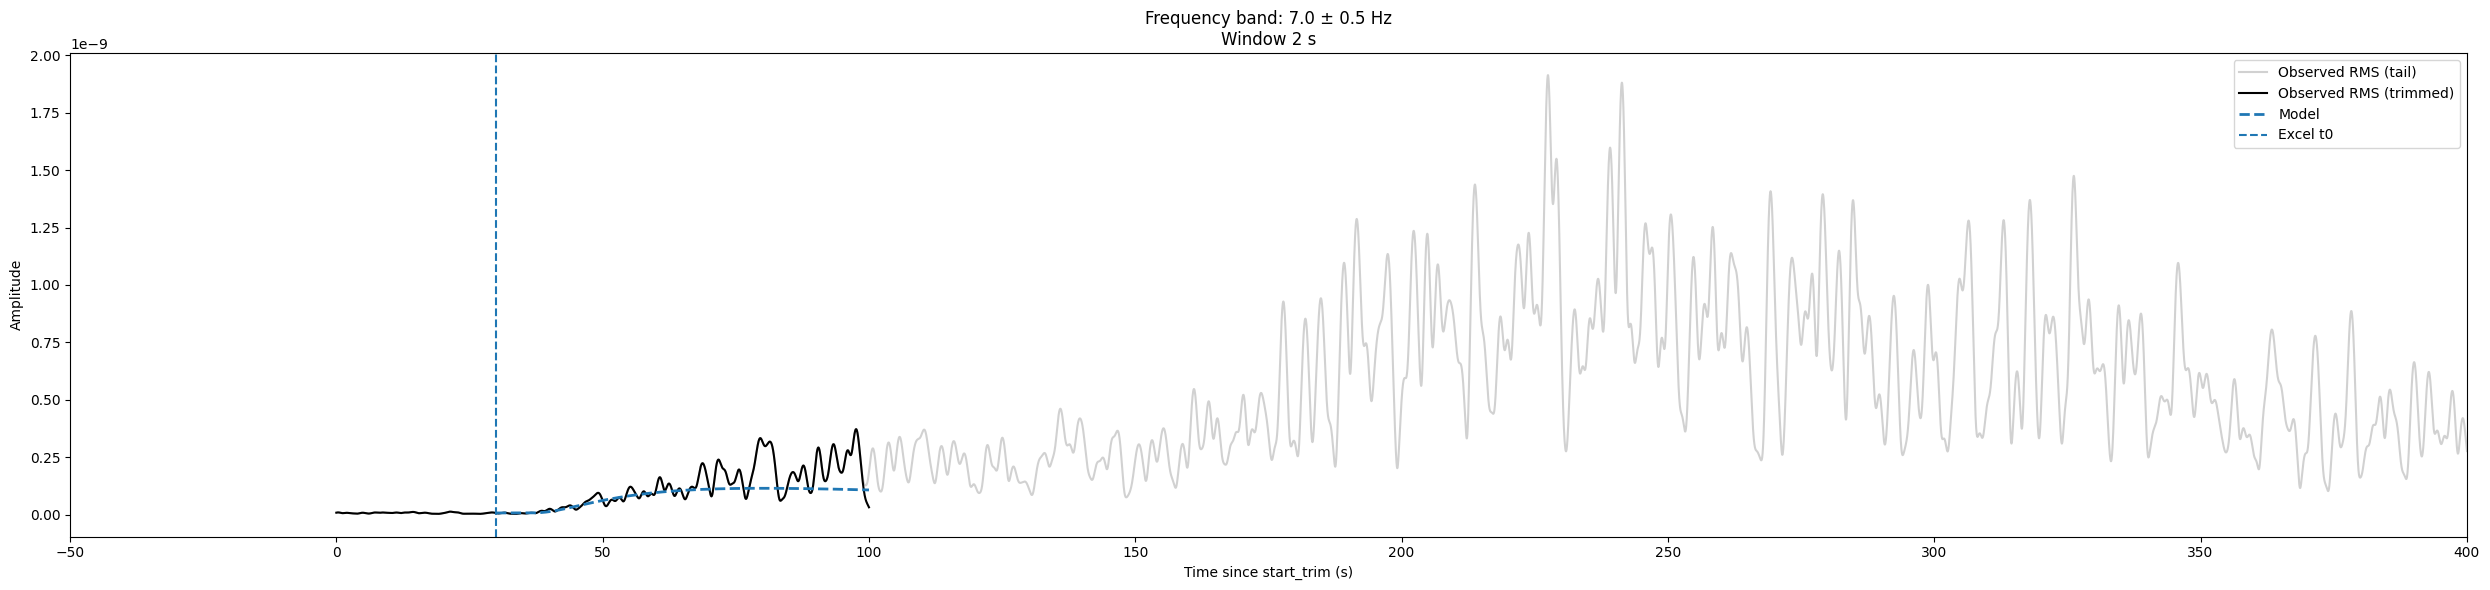


==== LOG fit (fit in log-amplitude) ====
n0 = 7.935e-12
A  = 3.359e-09
q  = 0.745034
a  = 1.287e-01 1/s
s  = 323.22 km
dt = 0.00 s
---- Misfit ----
RMS                  = 4.120e-11
Relative RMS         = 48.60 %
Log RMS              = 0.425

==== LINEAR fit (weighted) ====
n0 = 7.935e-12
A  = 4.771e-10
q  = 0.999999
a  = 6.855e-02 1/s
s  = 539.05 km
dt = 0.00 s
---- Misfit ----
WRMS (weighted)      = 0.350
RMS                  = 4.476e-11
Relative RMS         = 40.49 %
Log RMS              = 0.417


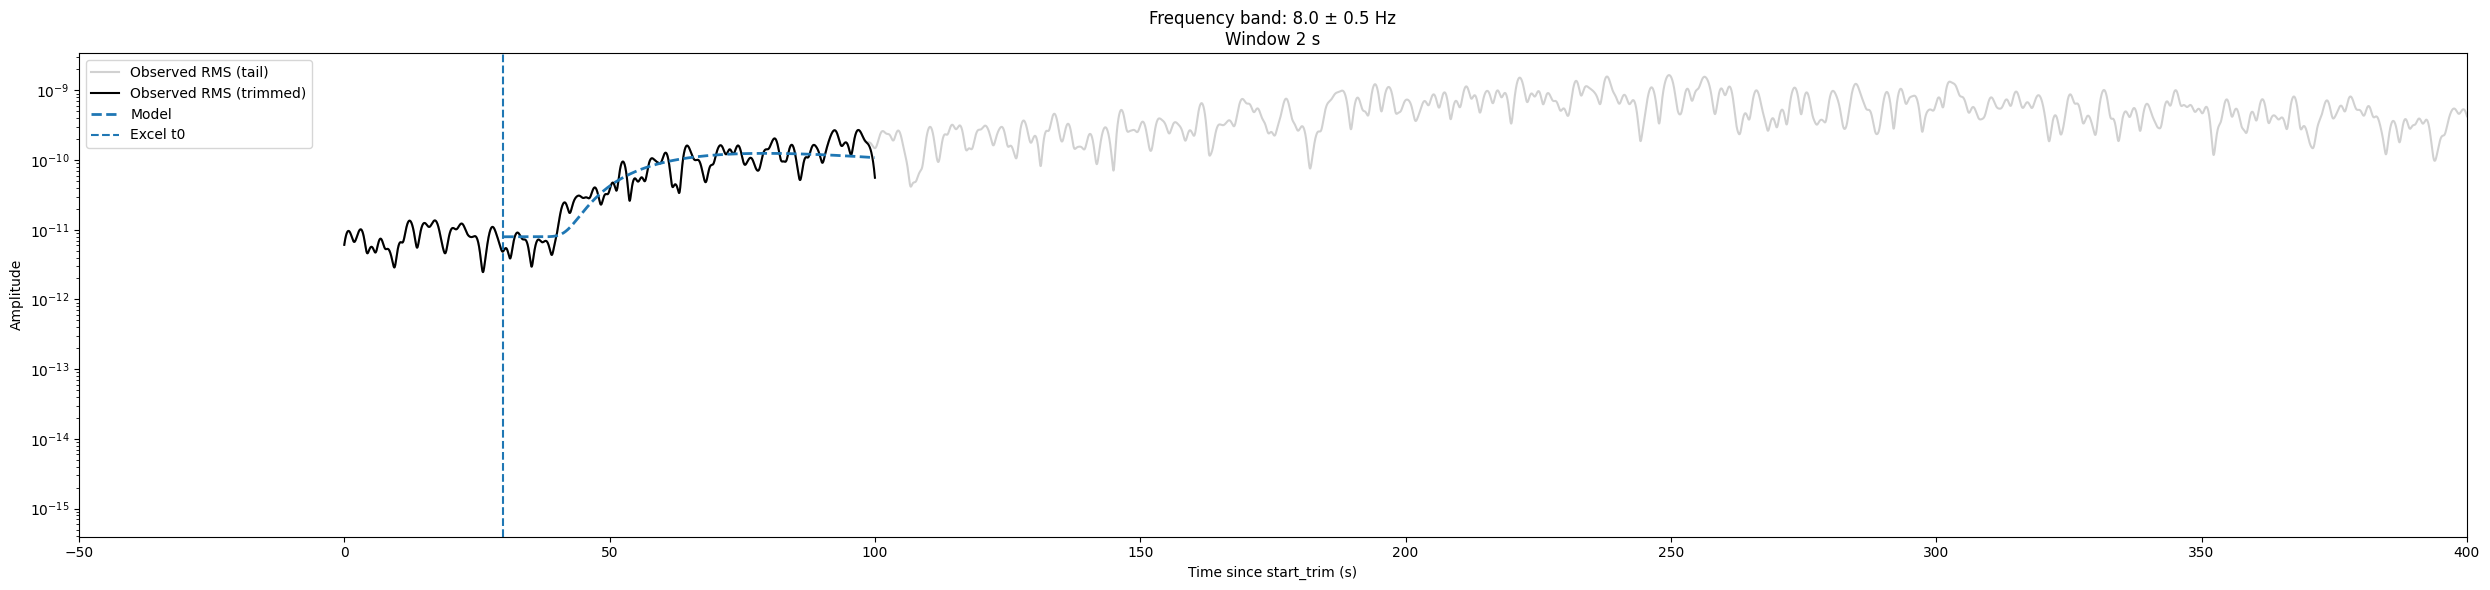

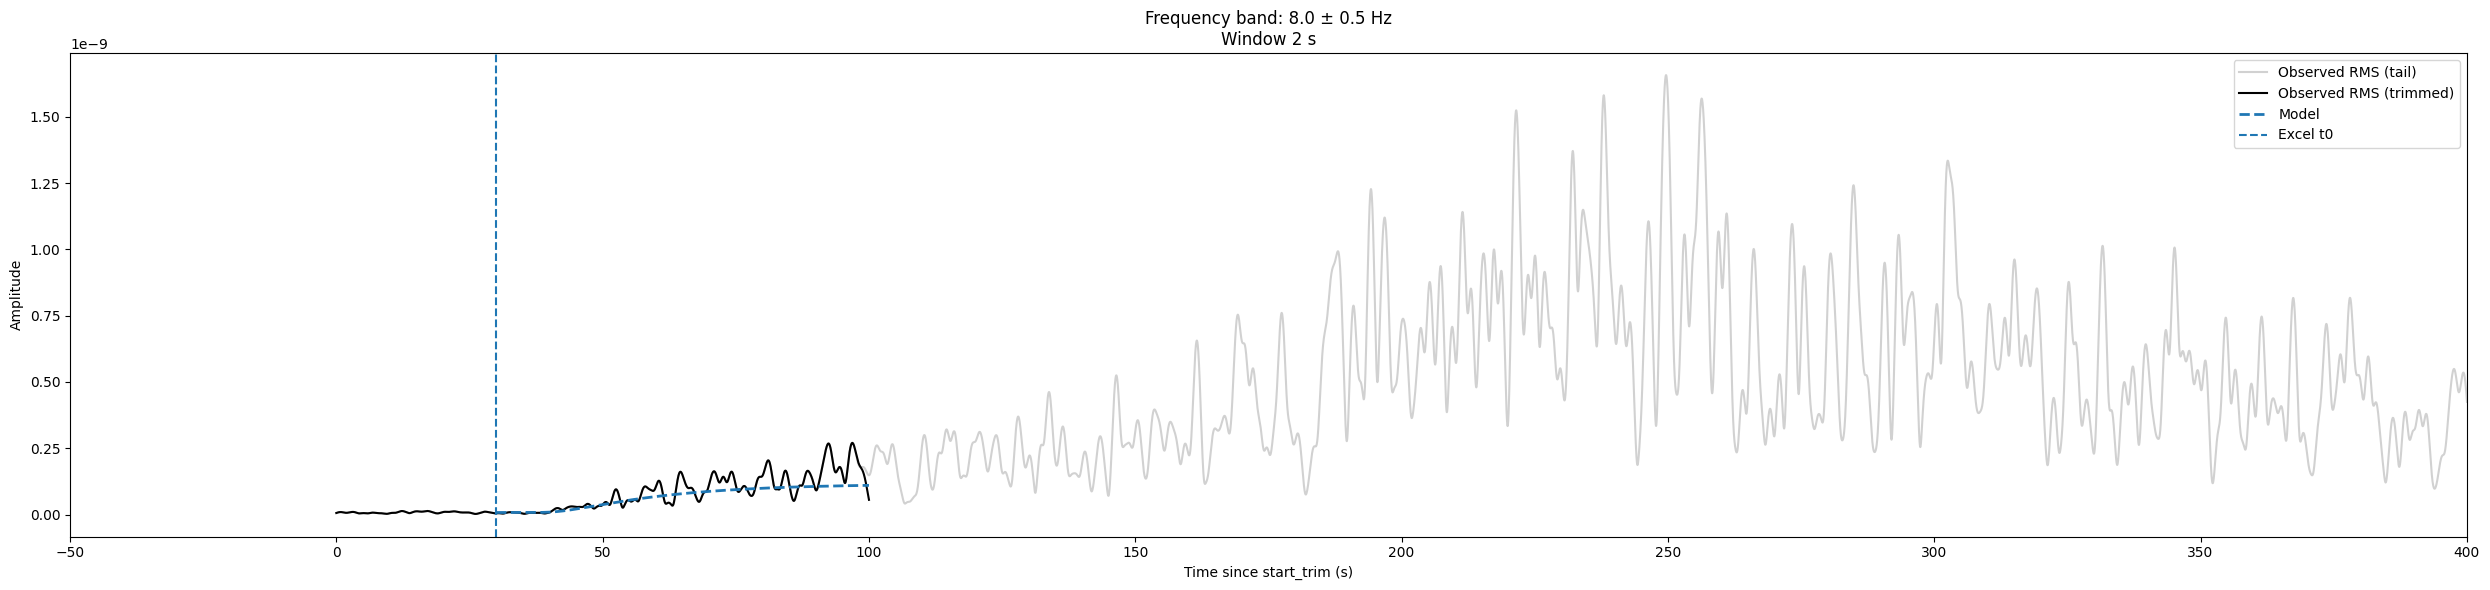

In [188]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from obspy import UTCDateTime

# 1) Pick trace/event (your function)
tr_chosen, chosen_event, chosen_row = select_trace_and_event_by_epicentral_distance(
    out_df,
    event_to_trace,
    target_deg=46,
    tol_deg=1.0,
    mode="closest"
)

# ============================================================
# Diffusion envelope: stable linear + stable log amplitude
# ============================================================

def _diffusion_log_e(tt, A, q, a, s, D):
    """
    log(amp_diff^2) without noise floor:
      amp_diff^2 = A^2 * q^(a t) / (a t) * exp( -D^2 / (s^2 a t) )
    """
    tt = np.asarray(tt, float)
    tt = np.maximum(tt, 1e-3)

    q = np.clip(q, 1e-12, 1 - 1e-12)
    a = np.maximum(a, 1e-12)
    s = np.maximum(s, 1e-6)
    A = np.maximum(A, 1e-30)

    return (
        2.0 * np.log(A)
        + (a * tt) * np.log(q)
        - np.log(a * tt)
        - (D**2) / (s**2 * a * tt)
    )

def diffusion_amp_floor(tt, A, q, a, s, D, n0, dt=0.0):
    """amp_total = sqrt( amp_diff(tt-dt)^2 + n0^2 )"""
    tt = np.asarray(tt, float)
    x = np.maximum(tt - dt, 1e-3)

    n0 = np.maximum(float(n0), 1e-30)
    log_e = _diffusion_log_e(x, A, q, a, s, D)
    return np.sqrt(np.exp(log_e) + n0**2)

def diffusion_logamp_floor(tt, A, q, a, s, D, n0, dt=0.0):
    """log(amp_total) in a numerically-stable way via logaddexp."""
    tt = np.asarray(tt, float)
    x = np.maximum(tt - dt, 1e-3)

    n0 = np.maximum(float(n0), 1e-30)
    log_e = _diffusion_log_e(x, A, q, a, s, D)      # log(amp_diff^2)
    log_n0sq = 2.0 * np.log(n0)                     # log(n0^2)

    # log(amp_total) = 0.5 * log( exp(log_e) + exp(log_n0sq) )
    return 0.5 * np.logaddexp(log_e, log_n0sq)

# ============================================================
# Shared helpers: masks, init/bounds, misfits
# ============================================================

def _prepare_fit_data(t, amp, t0_mean, tmin_after_t0):
    t = np.asarray(t, float)
    amp = np.asarray(amp, float)

    pre = t < (t0_mean-10)
    if not np.any(pre):
        raise RuntimeError("No samples before t0_mean for noise floor estimate.")
    n0 = float(np.mean(amp[pre]))  # r
    n0 = max(n0, 1e-30)

    t_eff = t - t0_mean
    mask = (t_eff > tmin_after_t0) & np.isfinite(amp) & (amp > 0)

    t_fit = t_eff[mask]
    amp_fit = amp[mask]

    if t_fit.size < 20:
        raise RuntimeError("Not enough valid samples after t0_mean for diffusion fit.")
    return n0, t_eff, t_fit, amp_fit

def _p0_bounds(amp_fit, D, fit_dt=True, n0=0): #A, q, a, s, dt
    # p0 tuned to be conservative and stable
    if fit_dt:
        p0 = (np.median(amp_fit), 0.98, 5e-3, max(D / 4, 1e-2), 0.0)
        bounds = (
            (1e-30, 1e-12, 1e-12, 1e-3,  -50),
            (1e+03, 1-1e-6, 2,   1e6,  +50),
        )
    else:
        p0 = (np.median(amp_fit), 0.98, 5e-3, max(D / 4, 1e-2))
        bounds = (
            (1e-30, 1e-12, 1e-12, 1e-3),
            (1e+03, 1-1e-6, 5,   1e6),
        )
    return p0, bounds

def _misfits(amp_obs, amp_pred, sigma=None):
    amp_obs = np.asarray(amp_obs, float)
    amp_pred = np.asarray(amp_pred, float)
    resid = amp_obs - amp_pred

    out = {}
    out["RMS"] = float(np.sqrt(np.mean(resid**2)))
    out["Relative_RMS"] = float(np.sqrt(np.mean((resid / amp_obs) ** 2)))
    out["Log_RMS"] = float(np.sqrt(np.mean((np.log(amp_obs) - np.log(amp_pred)) ** 2)))

    if sigma is not None:
        sigma = np.asarray(sigma, float)
        out["WRMS"] = float(np.sqrt(np.mean((resid / sigma) ** 2)))
    return out

def _print_fit(name, popt, n0, misfit):
    popt = np.asarray(popt, float)
    if popt.size == 5:
        A, q, a, s, dt = popt
    elif popt.size == 4:
        A, q, a, s = popt
        dt = 0.0
    else:
        raise ValueError(f"Unexpected number of parameters: {popt.size}")

    print(f"\n==== {name} ====")
    print(f"n0 = {n0:.3e}")
    print(f"A  = {A:.3e}")
    print(f"q  = {q:.6f}")
    print(f"a  = {a:.3e} 1/s")
    print(f"s  = {s:.2f} km")
    print(f"dt = {dt:.2f} s")

    print("---- Misfit ----")
    if "WRMS" in misfit:
        print(f"WRMS (weighted)      = {misfit['WRMS']:.3f}")
    print(f"RMS                  = {misfit['RMS']:.3e}")
    print(f"Relative RMS         = {100*misfit['Relative_RMS']:.2f} %")
    print(f"Log RMS              = {misfit['Log_RMS']:.3f}")


def _plot_fit(title, t_tail, amp_tail, t_trim, amp_trim, t0_line,
              t_model_abs, amp_model, semilogy=True):
    plt.figure(figsize=(25, 6))
    if semilogy:
        plt.semilogy(t_tail, amp_tail, color="0.7", alpha=0.6, label="Observed RMS (tail)")
        plt.semilogy(t_trim, amp_trim, color="k", label="Observed RMS (trimmed)")
        plt.semilogy(t_model_abs, amp_model, "--", lw=2, label="Model")
    else:
        plt.plot(t_tail, amp_tail, color="0.7", alpha=0.6, label="Observed RMS (tail)")
        plt.plot(t_trim, amp_trim, color="k", label="Observed RMS (trimmed)")
        plt.plot(t_model_abs, amp_model, "--", lw=2, label="Model")

    plt.axvline(t0_line, ls="--", label="Excel t0")
    plt.xlabel("Time since start_trim (s)")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.xlim(-50, 400)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ============================================================
# The 3 fits you asked for: (1) log fit, (2) linear, (3) linear weighted
# ============================================================

def fit_three_ways(
    t, amp, *, D, t0_mean, tmin_after_t0=0.0, fit_dt=True,
    weight_mode="hybrid",  # for linear-weighted
    maxfev=200_000
):
    """
    Returns dict with keys: 'log', 'linear', 'linear_weighted'
    Each entry has: popt, pcov, n0, t_fit, amp_fit, amp_pred_fit, misfit, (sigma for weighted)
    """
    n0, t_eff, t_fit, amp_fit = _prepare_fit_data(t, amp, t0_mean, tmin_after_t0)
    p0, bounds = _p0_bounds(amp_fit, D, fit_dt=fit_dt, n0=n0)

    # ---------- (1) LOG FIT ----------
    y_log = np.log(amp_fit)

    if fit_dt:
        def f_log(tt, A, q, a, s, dt):
            return diffusion_logamp_floor(tt, A, q, a, s, D, n0, dt)
        popt_log, pcov_log = curve_fit(f_log, t_fit, y_log, p0=p0, bounds=bounds, maxfev=maxfev)
        A, q, a, s, dt = popt_log
    else:
        def f_log(tt, A, q, a, s):
            return diffusion_logamp_floor(tt, A, q, a, s, D, n0, 0.0)
        popt_log, pcov_log = curve_fit(f_log, t_fit, y_log, p0=p0, bounds=bounds, maxfev=maxfev)
        A, q, a, s = popt_log
        dt = 0.0

    amp_pred_log = diffusion_amp_floor(t_fit, A, q, a, s, D, n0, dt)
    mis_log = _misfits(amp_fit, amp_pred_log)

    # # ---------- (2) LINEAR UNWEIGHTED ----------
    if fit_dt:
        def f_lin(tt, A, q, a, s, dt):
            return diffusion_amp_floor(tt, A, q, a, s, D, n0, dt)

    else:
        def f_lin(tt, A, q, a, s):
            return diffusion_amp_floor(tt, A, q, a, s, D, n0, 0.0)
   
   

    # ---------- (3) LINEAR WEIGHTED ----------
    if weight_mode == "hybrid":
        sigma = np.sqrt(amp_fit**2 + n0**2)
    elif weight_mode == "relative":
        sigma = np.maximum(amp_fit, n0)
    elif weight_mode == "noise":
        sigma = np.full_like(amp_fit, n0, dtype=float)
    else:
        raise ValueError("weight_mode must be one of: 'hybrid', 'relative', 'noise'")

    if fit_dt:
        popt_w, pcov_w = curve_fit(
            f_lin, t_fit, amp_fit,
            p0=p0, bounds=bounds,
            sigma=sigma, absolute_sigma=False,
            maxfev=maxfev
        )
        A3, q3, a3, s3, dt3 = popt_w
    else:
        popt_w, pcov_w = curve_fit(
            f_lin, t_fit, amp_fit,
            p0=p0, bounds=bounds,
            sigma=sigma, absolute_sigma=False,
            maxfev=maxfev
        )
        A3, q3, a3, s3 = popt_w
        dt3 = 0.0

    amp_pred_w = diffusion_amp_floor(t_fit, A3, q3, a3, s3, D, n0, dt3)
    mis_w = _misfits(amp_fit, amp_pred_w, sigma=sigma)

    return {
        "log": dict(popt=popt_log, pcov=pcov_log, n0=n0, t_fit=t_fit, amp_fit=amp_fit,
                    amp_pred_fit=amp_pred_log, misfit=mis_log),
        # "linear": dict(popt=popt_lin, pcov=pcov_lin, n0=n0, t_fit=t_fit, amp_fit=amp_fit,
        #                amp_pred_fit=amp_pred_lin, misfit=mis_lin),
        "linear_weighted": dict(popt=popt_w, pcov=pcov_w, n0=n0, t_fit=t_fit, amp_fit=amp_fit,
                                amp_pred_fit=amp_pred_w, sigma=sigma, misfit=mis_w),
    }

# ============================================================
# DROP-IN usage in your current script context

# ============================================================
print("Chosen event:", chosen_event)
print("Epi distance:", chosen_row["epi_deg"])


# 2) Excel t0 (UTC)
t0_utc = t0best_map[chosen_event]               # pd.Timestamp(UTC)
t0_obspy = UTCDateTime(t0_utc.to_pydatetime())  # ObsPy time

# 3) Define trim START (same for both), but:
#    - trimmed trace: trim start + fixed duration (end)
#    - "full tail" trace: trim start only (keep rest)
start_trim = t0_obspy - 30.0
end_trim = start_trim + 100  # only used for the short trimmed window

# 4) Create the short trimmed window (for fitting / close-up)
tr_trimmed = tr_chosen.copy()
tr_trimmed.trim(starttime=start_trim, endtime=end_trim)

# 5) Create the "full tail" trace: trim ONLY the beginning, keep the end
tr_tail = tr_chosen.copy()
tr_tail.trim(starttime=start_trim)  # <-- no endtime => keeps the rest of the trace

# Time axis for trimmed window (0 at start_trim)
t = tr_trimmed.times()

# t0 position on that axis
t0_line = float(t0_obspy - tr_trimmed.stats.starttime)


# ---- choose your band + smoothing params here ----
fc = 5.0
half_bw = 0.5
win_s = 2      # smoothing window seconds
order = 4       # bandpass filter order
frequency_bands = np.arange(3, 9, 1)
# --- trimmed RMS (fit window) ---
fs_trim = tr_trimmed.stats.sampling_rate
fs_tail = tr_tail.stats.sampling_rate
 # 7) Fit diffusion model on the trimmed RMS
    
D_km = float(chosen_row["epi_deg"]) * 30.0

t_tail = tr_tail.times()  # 0 at start_trim (same as t=0 for trimmed)

for fc_band in frequency_bands:
    fl, fu = band_edges(fc_band, half_bw, fs_trim)
    env_trim, rms = env_and_rms(tr_trimmed.data.astype(float), fs_trim, fl, fu, win_s, order)

    # --- tail RMS (same start as trimmed, but extends to end) ---
    fl_t, fu_t = band_edges(fc_band, half_bw, fs_tail)
    env_tail, rms_tail = env_and_rms(tr_tail.data.astype(float), fs_tail, fl_t, fu_t, win_s, order)

   
    # Do the 3 fits
    res = fit_three_ways(
        t, rms,
        D=D_km,
        t0_mean=t0_line,
        tmin_after_t0= - win_s/2,   #Which observed samples are allowed to inform the fit?
        fit_dt=False,        # set to True to fit a time shift (dt) fixes the model time origin to your picked  t0! Can diffusion start earlier/later than to??
        weight_mode="hybrid"
    )

    # Print parameter values + misfits
    _print_fit("LOG fit (fit in log-amplitude)", res["log"]["popt"], res["log"]["n0"], res["log"]["misfit"])
    _print_fit("LINEAR fit (weighted)",          res["linear_weighted"]["popt"], res["linear_weighted"]["n0"], res["linear_weighted"]["misfit"])

    # Build a common model axis for plotting on your trimmed window:
    t_eff_all = t - t0_line
    t_model = t_eff_all[t_eff_all > 0]
    t_model_abs = t_model + t0_line

    plot_specs = {
        "log": {
            "title": f"Frequency band: {fc_band:.1f} ± {half_bw:.1f} Hz\nWindow {win_s} s",
            "semilogy": True,
        },

        "linear_weighted": {
            "title": f"Frequency band: {fc_band:.1f} ± {half_bw:.1f} Hz\nWindow {win_s} s",
            "semilogy": False,
        },
    }

    for key, spec in plot_specs.items():
        popt = res[key]["popt"]
        n0 = res[key]["n0"]

        popt = np.asarray(res[key]["popt"], float)

        if popt.size == 5:
            A, q, a, s, dt = popt
        else:
            A, q, a, s = popt
            dt = 0.0

        amp_model = diffusion_amp_floor(
            t_model, A, q, a, s, D_km, n0, dt
        )

        _plot_fit(
            title=spec["title"],
            t_tail=t_tail,
            amp_tail=rms_tail,
            t_trim=t,
            amp_trim=rms,
            t0_line=t0_line,
            t_model_abs=t_model_abs,
            amp_model=amp_model,
            semilogy=spec["semilogy"],  # <-- scale chosen here
        )


Chosen event: 1976-03-06 10:03:00.009000+00:00__S14
Epi distance: 56.58004741455963
t0_line (s since start_trim): 29.991855
D_km: 1697.4014224367888
Number of bands: 7


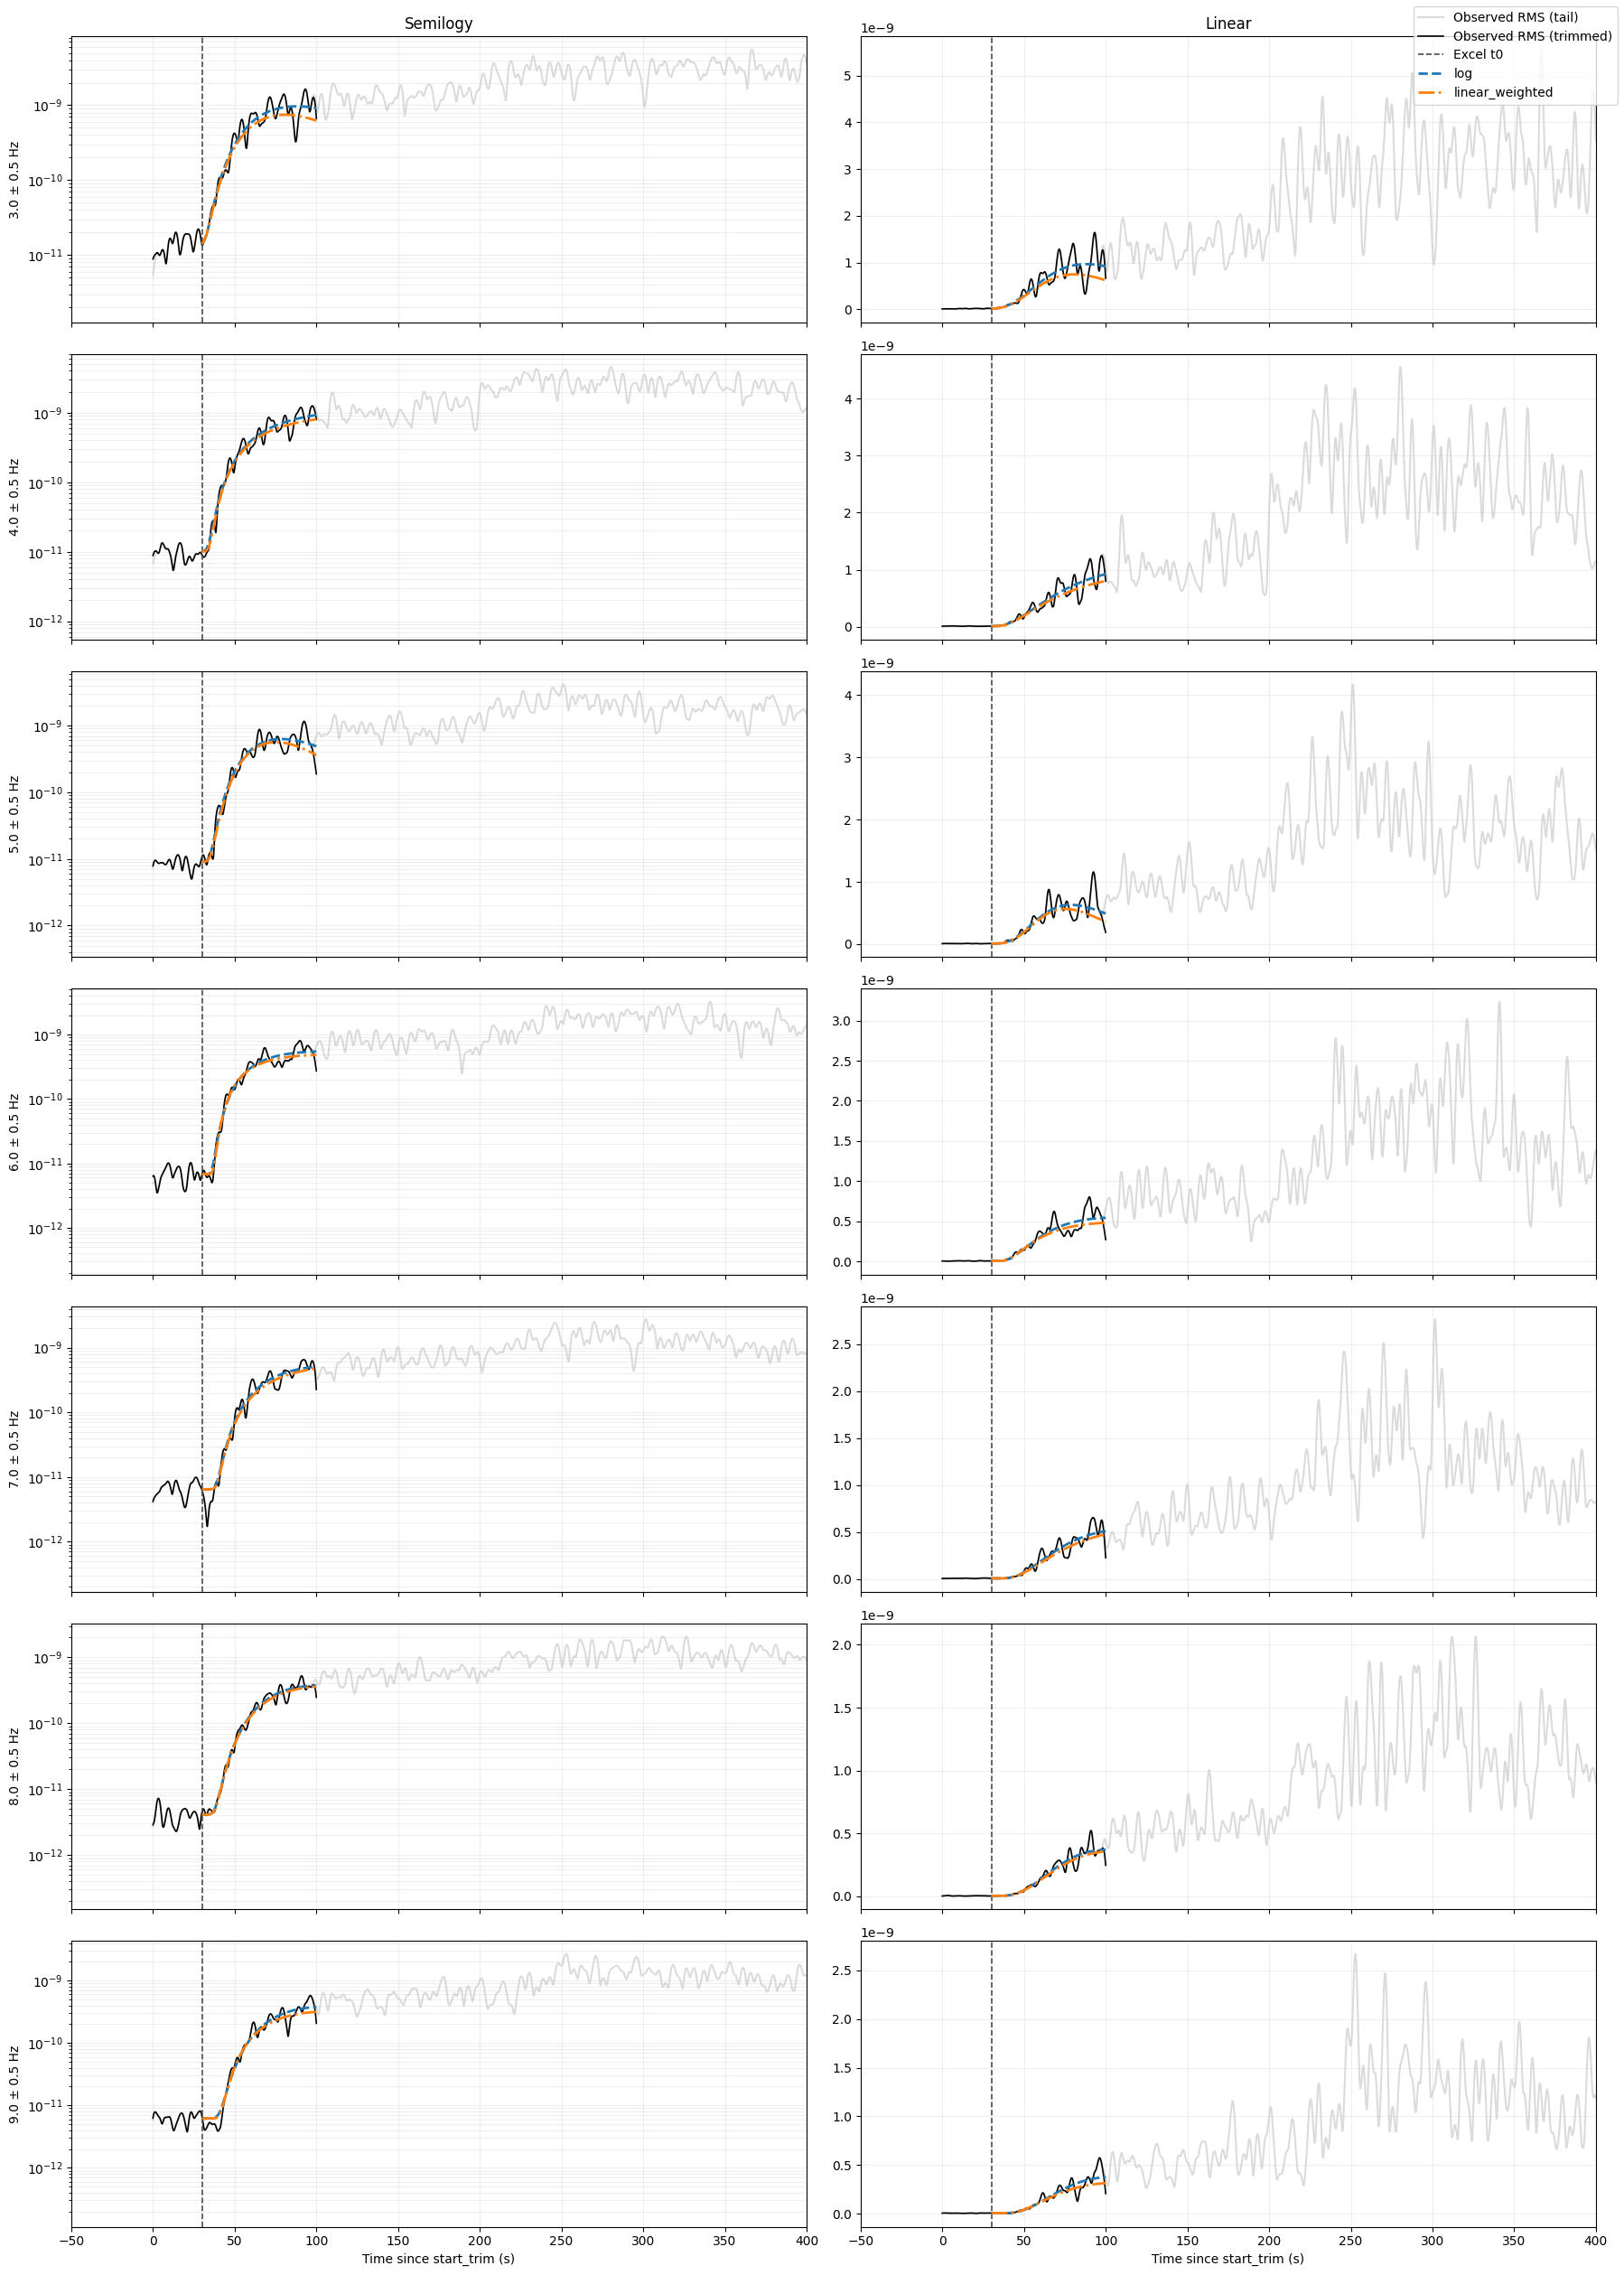

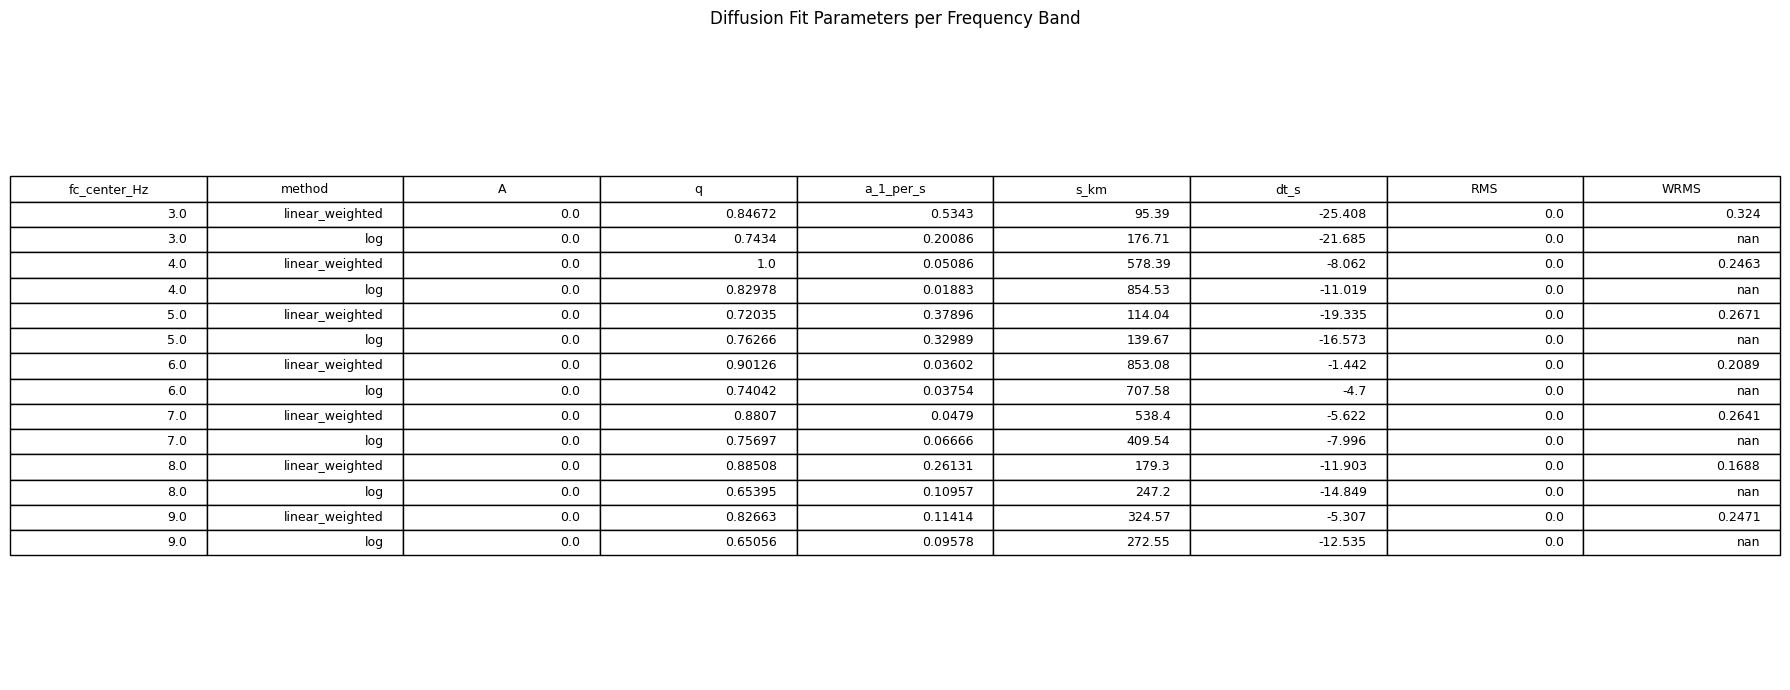

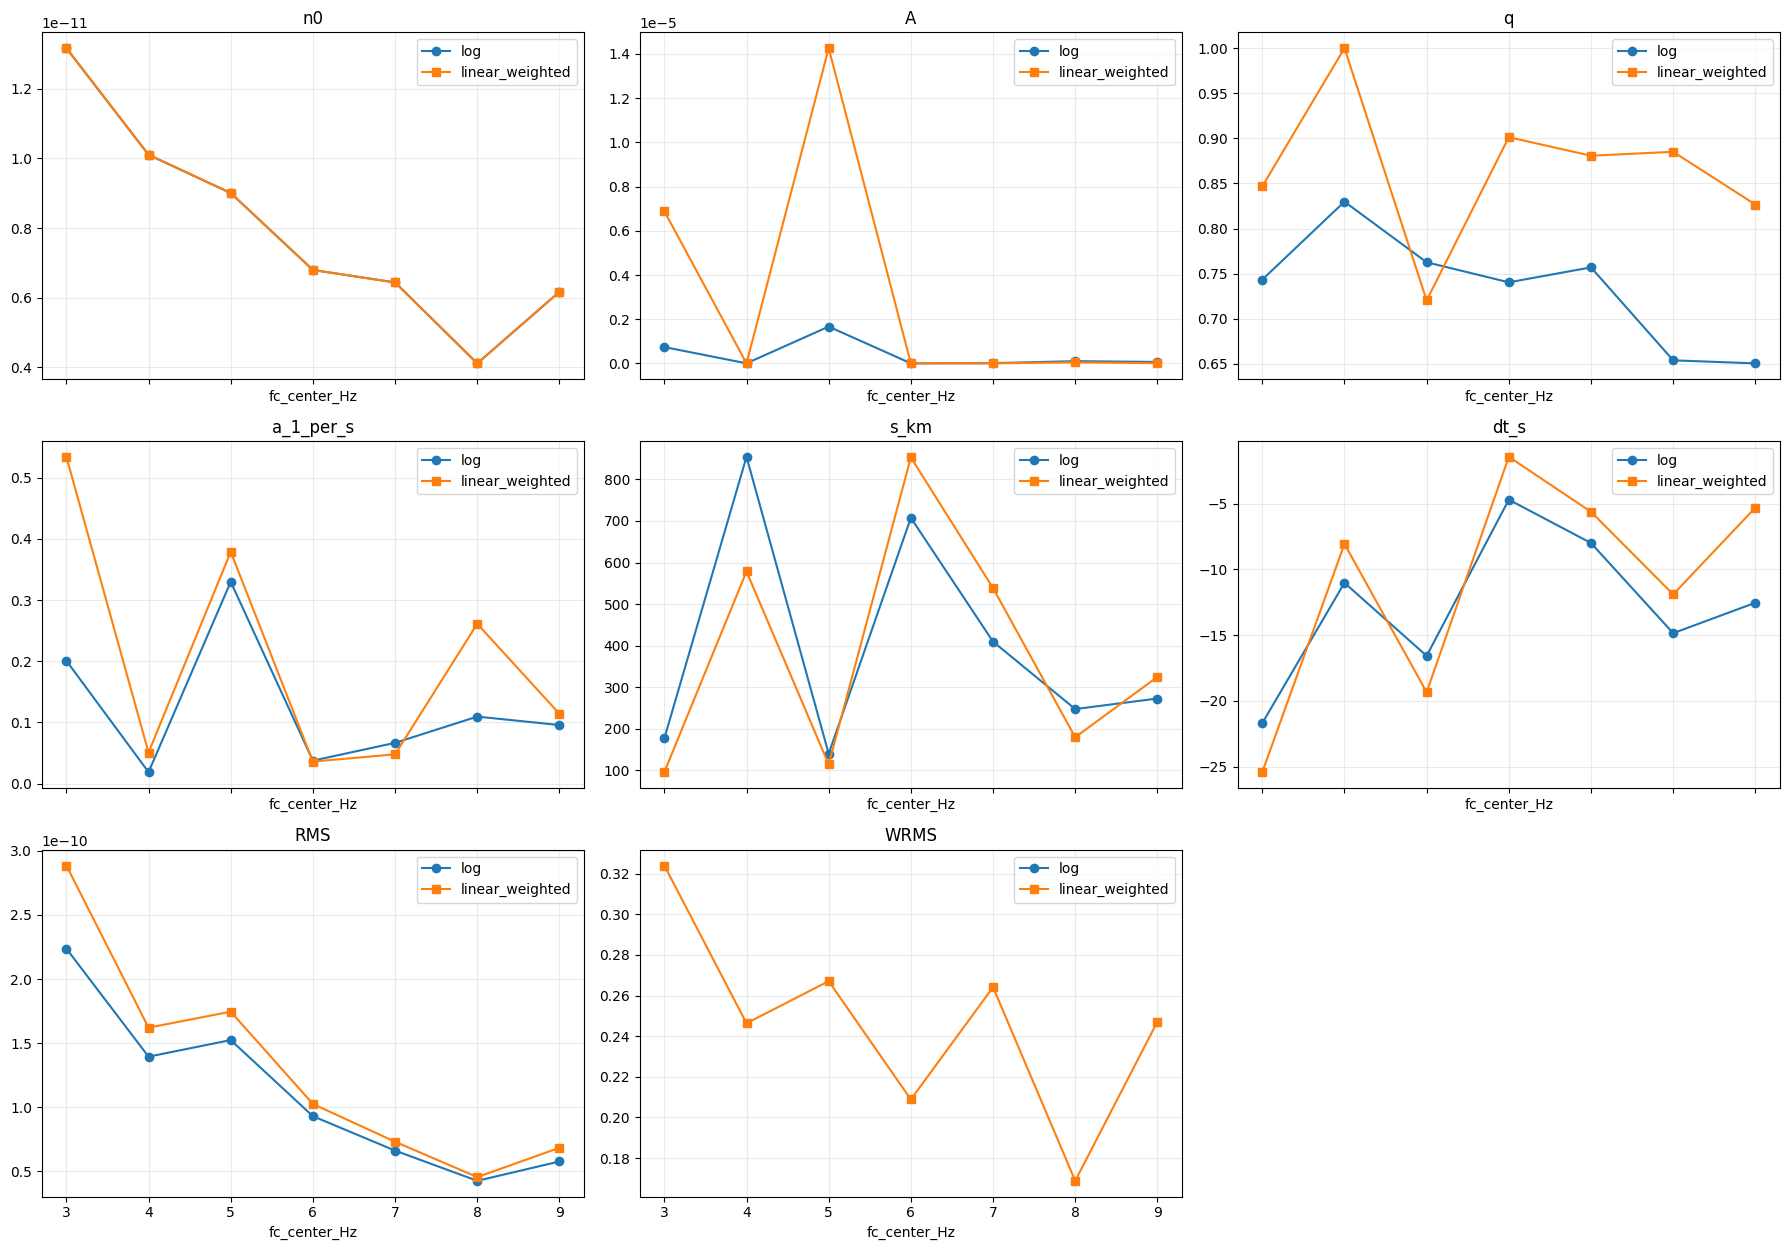

In [208]:
# ============================================================
# FULL SCRIPT (single code cell)
# - Select trace/event near target epicentral distance
# - Define diffusion model (stable log + noise floor)
# - Fit per band using (1) log-fit, (2) linear weighted
# - Make ONE figure: 2 columns × N rows (1 row per band)
# - Build a table (DataFrame) with values per band + method
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from obspy import UTCDateTime

# ============================================================
# 0) REQUIRED external helpers you already have in your project
# ============================================================
# You must have these defined somewhere in your codebase:
# - select_trace_and_event_by_epicentral_distance(out_df, event_to_trace, target_deg, tol_deg, mode)
# - band_edges(fc, half_bw, fs) -> (fl, fu)
# - env_and_rms(x, fs, fl, fu, win_s, order) -> (env, rms)
#
# If they are not defined, this script will fail.
# ============================================================


# ============================================================
# 1) Pick trace/event (your function)
# ============================================================
tr_chosen, chosen_event, chosen_row = select_trace_and_event_by_epicentral_distance(
    out_df,
    event_to_trace,
    target_deg=56,
    tol_deg=1.0,
    mode="closest"
)

print("Chosen event:", chosen_event)
print("Epi distance:", chosen_row["epi_deg"])


# ============================================================
# 2) Diffusion envelope: stable linear + stable log amplitude
# ============================================================
def _diffusion_log_e(tt, A, q, a, s, D):
    """
    log(amp_diff^2) without noise floor:
      amp_diff^2 = A^2 * q^(a t) / (a t) * exp( -D^2 / (s^2 a t) )
    """
    tt = np.asarray(tt, float)
    tt = np.maximum(tt, 1e-3)

    q = np.clip(q, 1e-12, 1 - 1e-12)
    a = np.maximum(a, 1e-12)
    s = np.maximum(s, 1e-6)
    A = np.maximum(A, 1e-30)

    return (
        2.0 * np.log(A)
        + (a * tt) * np.log(q)
        - np.log(a * tt)
        - (D**2) / (s**2 * a * tt)
    )

def diffusion_amp_floor(tt, A, q, a, s, D, n0, dt=0.0):
    """amp_total = sqrt( amp_diff(tt-dt)^2 + n0^2 )"""
    tt = np.asarray(tt, float)
    x = np.maximum(tt - dt, 1e-3)

    n0 = np.maximum(float(n0), 1e-30)
    log_e = _diffusion_log_e(x, A, q, a, s, D)
    return np.sqrt(np.exp(log_e) + n0**2)

def diffusion_logamp_floor(tt, A, q, a, s, D, n0, dt=0.0):
    """log(amp_total) stably via logaddexp."""
    tt = np.asarray(tt, float)
    x = np.maximum(tt - dt, 1e-3)

    n0 = np.maximum(float(n0), 1e-30)
    log_e = _diffusion_log_e(x, A, q, a, s, D)      # log(amp_diff^2)
    log_n0sq = 2.0 * np.log(n0)                     # log(n0^2)

    return 0.5 * np.logaddexp(log_e, log_n0sq)


# ============================================================
# 3) Shared helpers: masks, init/bounds, misfits
# ============================================================
def _prepare_fit_data(t, amp, t0_mean, tmin_after_t0):
    t = np.asarray(t, float)
    amp = np.asarray(amp, float)

    pre = t < (t0_mean - 10)
    if not np.any(pre):
        raise RuntimeError("No samples before t0_mean for noise floor estimate.")
    n0 = float(np.mean(amp[pre]))
    n0 = max(n0, 1e-30)

    t_eff = t - t0_mean
    mask = (t_eff > tmin_after_t0) & np.isfinite(amp) & (amp > 0)

    t_fit = t_eff[mask]
    amp_fit = amp[mask]

    if t_fit.size < 20:
        raise RuntimeError("Not enough valid samples after t0_mean for diffusion fit.")
    return n0, t_eff, t_fit, amp_fit

def _p0_bounds(amp_fit, D, fit_dt=True):
    if fit_dt:
        p0 = (np.median(amp_fit), 0.98, 5e-3, max(D / 4, 1e-2), 0.0)
        bounds = (
            (1e-30, 1e-12, 1e-12, 1e-3,  -50),
            (1e+03, 1-1e-6, 2.0,  1e6,  +50),
        )
    else:
        p0 = (np.median(amp_fit), 0.98, 5e-3, max(D / 4, 1e-2))
        bounds = (
            (1e-30, 1e-12, 1e-12, 1e-3),
            (1e+03, 1-1e-6, 5.0,  1e6),
        )
    return p0, bounds

def _misfits(amp_obs, amp_pred, sigma=None):
    amp_obs = np.asarray(amp_obs, float)
    amp_pred = np.asarray(amp_pred, float)
    resid = amp_obs - amp_pred

    out = {}
    out["RMS"] = float(np.sqrt(np.mean(resid**2)))
    out["Relative_RMS"] = float(np.sqrt(np.mean((resid / amp_obs) ** 2)))
    out["Log_RMS"] = float(np.sqrt(np.mean((np.log(amp_obs) - np.log(amp_pred)) ** 2)))

    if sigma is not None:
        sigma = np.asarray(sigma, float)
        out["WRMS"] = float(np.sqrt(np.mean((resid / sigma) ** 2)))
    return out


# ============================================================
# 4) Fit: (1) log-fit, (2) linear weighted
# ============================================================
def fit_three_ways(
    t, amp, *, D, t0_mean, tmin_after_t0=0.0, fit_dt=False,
    weight_mode="hybrid",
    maxfev=200_000
):
    """
    Returns dict with keys: 'log', 'linear_weighted'
    Each entry has: popt, pcov, n0, t_fit, amp_fit, amp_pred_fit, misfit (+sigma for weighted)
    """
    n0, t_eff, t_fit, amp_fit = _prepare_fit_data(t, amp, t0_mean, tmin_after_t0)
    p0, bounds = _p0_bounds(amp_fit, D, fit_dt=fit_dt)

    # ---------- (1) LOG FIT ----------
    y_log = np.log(amp_fit)

    if fit_dt:
        def f_log(tt, A, q, a, s, dt):
            return diffusion_logamp_floor(tt, A, q, a, s, D, n0, dt)
        popt_log, pcov_log = curve_fit(f_log, t_fit, y_log, p0=p0, bounds=bounds, maxfev=maxfev)
        A, q, a, s, dt = popt_log
    else:
        def f_log(tt, A, q, a, s):
            return diffusion_logamp_floor(tt, A, q, a, s, D, n0, 0.0)
        popt_log, pcov_log = curve_fit(f_log, t_fit, y_log, p0=p0, bounds=bounds, maxfev=maxfev)
        A, q, a, s = popt_log
        dt = 0.0

    amp_pred_log = diffusion_amp_floor(t_fit, A, q, a, s, D, n0, dt)
    mis_log = _misfits(amp_fit, amp_pred_log)

    # ---------- (2) LINEAR WEIGHTED ----------
    if weight_mode == "hybrid":
        sigma = np.sqrt(amp_fit**2 + n0**2)
    elif weight_mode == "relative":
        sigma = np.maximum(amp_fit, n0)
    elif weight_mode == "noise":
        sigma = np.full_like(amp_fit, n0, dtype=float)
    else:
        raise ValueError("weight_mode must be one of: 'hybrid', 'relative', 'noise'")

    if fit_dt:
        def f_lin(tt, A, q, a, s, dt):
            return diffusion_amp_floor(tt, A, q, a, s, D, n0, dt)
        popt_w, pcov_w = curve_fit(
            f_lin, t_fit, amp_fit,
            p0=p0, bounds=bounds,
            sigma=sigma, absolute_sigma=False,
            maxfev=maxfev
        )
        A3, q3, a3, s3, dt3 = popt_w
    else:
        def f_lin(tt, A, q, a, s):
            return diffusion_amp_floor(tt, A, q, a, s, D, n0, 0.0)
        popt_w, pcov_w = curve_fit(
            f_lin, t_fit, amp_fit,
            p0=p0, bounds=bounds,
            sigma=sigma, absolute_sigma=False,
            maxfev=maxfev
        )
        A3, q3, a3, s3 = popt_w
        dt3 = 0.0

    amp_pred_w = diffusion_amp_floor(t_fit, A3, q3, a3, s3, D, n0, dt3)
    mis_w = _misfits(amp_fit, amp_pred_w, sigma=sigma)

    return {
        "log": dict(
            popt=popt_log, pcov=pcov_log, n0=n0,
            t_fit=t_fit, amp_fit=amp_fit, amp_pred_fit=amp_pred_log,
            misfit=mis_log
        ),
        "linear_weighted": dict(
            popt=popt_w, pcov=pcov_w, n0=n0,
            t_fit=t_fit, amp_fit=amp_fit, amp_pred_fit=amp_pred_w,
            sigma=sigma, misfit=mis_w
        ),
    }


# ============================================================
# 5) Time trimming + setup
# ============================================================
# Excel t0 (UTC)
t0_utc = t0best_map[chosen_event]               # pd.Timestamp(UTC)
t0_obspy = UTCDateTime(t0_utc.to_pydatetime())

# Trim window definition
start_trim = t0_obspy - 30.0
end_trim   = start_trim + 100

# Short trimmed trace (for fitting)
tr_trimmed = tr_chosen.copy()
tr_trimmed.trim(starttime=start_trim, endtime=end_trim)

# Long tail trace (for plotting tail)
tr_tail = tr_chosen.copy()
tr_tail.trim(starttime=start_trim)  # keep the rest

# Time axis for trimmed window (0 at start_trim)
t = tr_trimmed.times()
t_tail = tr_tail.times()

# t0 position on trimmed axis
t0_line = float(t0_obspy - tr_trimmed.stats.starttime)

# Choose smoothing/bands
half_bw = 0.5
win_s   = 5
order   = 4

# NOTE: This gives 12 bands (3.0 ... 8.5). If you truly want 7 rows,
#       set bands accordingly (example below).
frequency_bands = np.arange(3, 9.5, 1)

# If you want EXACTLY 7 rows, use something like:
# frequency_bands = np.arange(3.0, 6.5 + 0.5, 0.5)  # 3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5 => 8 rows
# frequency_bands = np.array([3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0]) # 7 rows EXACT

fs_trim = tr_trimmed.stats.sampling_rate
fs_tail = tr_tail.stats.sampling_rate

# Epicentral distance in km (your rule)
D_km = float(chosen_row["epi_deg"]) * 30.0

print("t0_line (s since start_trim):", t0_line)
print("D_km:", D_km)
print("Number of bands:", len(frequency_bands))


# ============================================================
# 6) Loop bands: compute RMS, fit, store table rows, and plot 2×N figure
# ============================================================
methods = ["log", "linear_weighted"]
linestyles = {"log": "--", "linear_weighted": "-."}

n_bands = len(frequency_bands)
fig, axes = plt.subplots(
    nrows=n_bands,
    ncols=2,
    figsize=(18, 3.6 * n_bands),
    sharex=True
)

if n_bands == 1:
    axes = np.array([axes])

rows = []

for i, fc_band in enumerate(frequency_bands):
    # --- trimmed RMS ---
    fl, fu = band_edges(fc_band, half_bw, fs_trim)
    env_trim, rms = env_and_rms(tr_trimmed.data.astype(float), fs_trim, fl, fu, win_s, order)

    # --- tail RMS ---
    fl_t, fu_t = band_edges(fc_band, half_bw, fs_tail)
    env_tail, rms_tail = env_and_rms(tr_tail.data.astype(float), fs_tail, fl_t, fu_t, win_s, order)

    # --- fit ---
    res = fit_three_ways(
        t, rms,
        D=D_km,
        t0_mean=t0_line,
        tmin_after_t0=-win_s/2,
        fit_dt=True,
        weight_mode="hybrid"
    )

    # --- model axis only after t0 ---
    t_eff_all = t - t0_line
    mask_model = t_eff_all > 0
    t_model = t_eff_all[mask_model]
    t_model_abs = t_model + t0_line

    # --- axes for this row ---
    ax_log = axes[i, 0]
    ax_lin = axes[i, 1]

    # Observations (label only once for shared legend)
    ax_log.semilogy(t_tail, rms_tail, color="0.8", alpha=0.7, label="Observed RMS (tail)" if i == 0 else None)
    ax_log.semilogy(t, rms, color="k", lw=1.2, label="Observed RMS (trimmed)" if i == 0 else None)

    ax_lin.plot(t_tail, rms_tail, color="0.8", alpha=0.7, label="Observed RMS (tail)" if i == 0 else None)
    ax_lin.plot(t, rms, color="k", lw=1.2, label="Observed RMS (trimmed)" if i == 0 else None)

    # t0 line
    ax_log.axvline(t0_line, ls="--", lw=1.2, color="0.3", label="Excel t0" if i == 0 else None)
    ax_lin.axvline(t0_line, ls="--", lw=1.2, color="0.3", label="Excel t0" if i == 0 else None)

    # Overlay both fitted models + store table rows
    for method in methods:
        popt = np.asarray(res[method]["popt"], float)
        n0 = float(res[method]["n0"])
        mis = res[method]["misfit"]

        if popt.size == 5:
            A, q, a, s, dt = popt
        else:
            A, q, a, s = popt
            dt = 0.0

        amp_model = diffusion_amp_floor(t_model, A, q, a, s, D_km, n0, dt)

        ax_log.semilogy(
            t_model_abs, amp_model,
            ls=linestyles[method], lw=2.0,
            label=method if i == 0 else None
        )
        ax_lin.plot(
            t_model_abs, amp_model,
            ls=linestyles[method], lw=2.0,
            label=method if i == 0 else None
        )

        rows.append({
            "fc_center_Hz": float(fc_band),
            "f_low_Hz": float(fc_band - half_bw),
            "f_high_Hz": float(fc_band + half_bw),
            "half_bw_Hz": float(half_bw),
            "win_s": float(win_s),
            "order": int(order),
            "D_km": float(D_km),
            "t0_line_s": float(t0_line),
            "method": method,
            "n0": n0,
            "A": float(A),
            "q": float(q),
            "a_1_per_s": float(a),
            "s_km": float(s),
            "dt_s": float(dt),
            "RMS": float(mis["RMS"]),
            "Relative_RMS": float(mis["Relative_RMS"]),
            "Log_RMS": float(mis["Log_RMS"]),
            "WRMS": float(mis.get("WRMS", np.nan)),
        })

    # Row formatting
    for ax in (ax_log, ax_lin):
        ax.set_xlim(-50, 400)
        ax.grid(True, which="both", alpha=0.2)

    ax_log.set_ylabel(f"{fc_band:.1f} ± {half_bw:.1f} Hz")

    if i == 0:
        ax_log.set_title("Semilogy")
        ax_lin.set_title("Linear")

    if i == n_bands - 1:
        ax_log.set_xlabel("Time since start_trim (s)")
        ax_lin.set_xlabel("Time since start_trim (s)")

# Global legend (from first row)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

# ============================================================
# 7) Create a formatted table in the figure (no printing)
# ============================================================

df_bands = (
    pd.DataFrame(rows)
    .sort_values(["fc_center_Hz", "method"])
    .reset_index(drop=True)
)

# Round values for readability
df_display = df_bands.copy()
df_display = df_display.round({
    "A": 4,
    "q": 5,
    "a_1_per_s": 5,
    "s_km": 2,
    "dt_s": 3,
    "RMS": 4,
    "Relative_RMS": 4,
    "Log_RMS": 4,
    "WRMS": 4,
})

# Select only the columns you want to show
cols_to_show = [
    "fc_center_Hz",
    "method",
    "A",
    "q",
    "a_1_per_s",
    "s_km",
    "dt_s",
    "RMS",
    "WRMS"
]

df_display = df_display[cols_to_show]

# ---- Create table figure ----
fig_table, ax_table = plt.subplots(figsize=(18, 0.5 * len(df_display)))
ax_table.axis("off")

table = ax_table.table(
    cellText=df_display.values,
    colLabels=df_display.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.3)

plt.title("Diffusion Fit Parameters per Frequency Band", pad=20)
plt.tight_layout()
plt.show()
# ============================================================
# 8) Parameter-vs-frequency summary figure (subplots)
# ============================================================

# Ensure df exists
df_bands = (
    pd.DataFrame(rows)
    .sort_values(["fc_center_Hz", "method"])
    .reset_index(drop=True)
)

# Parameters to plot
params = ["n0", "A", "q", "a_1_per_s", "s_km", "dt_s", "RMS", "WRMS"]

# Pivot: index = frequency, columns = method, values = parameter
wide = {}
for p in params:
    wide[p] = df_bands.pivot(index="fc_center_Hz", columns="method", values=p)

# Subplot layout
n = len(params)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4.2 * nrows), sharex=True)
axes = np.atleast_2d(axes).ravel()

for ax, p in zip(axes, params):
    w = wide[p]

    # x = frequencies
    x = w.index.values

    # plot both methods if present
    if "log" in w.columns:
        ax.plot(x, w["log"].values, marker="o", label="log")
    if "linear_weighted" in w.columns:
        ax.plot(x, w["linear_weighted"].values, marker="s", label="linear_weighted")

    ax.set_title(p)
    ax.set_xlabel("fc_center_Hz")
    ax.grid(True, alpha=0.25)
    ax.legend(frameon=True)

# Hide unused axes
for ax in axes[len(params):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
